# Heart Disease Prediction Experiments

This notebook is a self-contained implementation of the heart disease prediction experiments.

The notebook follows a clean architecture structure inside the notebook itself:

1. Configuration
2. Data layer
3. Feature and preprocessing layer
4. Model layer
5. Evaluation layer
6. Visualization layer
7. Experiments

All reported metrics are generated by running the notebook. No result values are manually inserted.

## 1. Configuration

This section defines reproducibility settings, paths, and experiment switches.

In [1]:
from __future__ import annotations

import math
import random
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from scipy.io import arff

from sklearn.base import BaseEstimator, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")


@dataclass(frozen=True)
class NotebookConfig:
    """Notebook runtime configuration.

    Attributes:
        project_root: Repository/project root path.
        random_state: Random seed used across experiments.
        output_dir: Directory for generated tables and figures.
        run_kaggle_experiment: Whether to run the large Kaggle CVD experiment.
        run_uci_experiment: Whether to run UCI benchmark experiments.
        run_openml_benchmark: Whether to run OpenML baseline benchmark.
        run_openml_tuning: Whether to run OpenML hyperparameter tuning.
        run_xai_experiment: Whether to run SHAP explainability.
        run_feature_selection_experiment: Whether to run feature selection experiments.
        run_ft_transformer_experiment: Whether to run FT-Transformer experiment.
        ft_transformer_epochs: Maximum FT-Transformer training epochs.
    """

    project_root: Path
    random_state: int
    output_dir: Path
    run_kaggle_experiment: bool = True
    run_uci_experiment: bool = True
    run_openml_benchmark: bool = True
    run_openml_tuning: bool = True
    run_xai_experiment: bool = True
    run_feature_selection_experiment: bool = True
    run_ft_transformer_experiment: bool = True
    ft_transformer_epochs: int = 80


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG = NotebookConfig(
    project_root=PROJECT_ROOT,
    random_state=42,
    output_dir=PROJECT_ROOT / "outputs" / "clean_notebook",
    run_kaggle_experiment=True,
    run_uci_experiment=True,
    run_openml_benchmark=True,
    run_openml_tuning=True,
    run_xai_experiment=True,
    run_feature_selection_experiment=True,
    run_ft_transformer_experiment=True,
    ft_transformer_epochs=80,
)

CONFIG.output_dir.mkdir(parents=True, exist_ok=True)
random.seed(CONFIG.random_state)
np.random.seed(CONFIG.random_state)
torch.manual_seed(CONFIG.random_state)
torch.set_num_threads(1)

print(CONFIG)

NotebookConfig(project_root=WindowsPath('D:/Freelance work/Mohamed Magied'), random_state=42, output_dir=WindowsPath('D:/Freelance work/Mohamed Magied/outputs/clean_notebook'), run_kaggle_experiment=True, run_uci_experiment=True, run_openml_benchmark=True, run_openml_tuning=True, run_xai_experiment=True, run_feature_selection_experiment=True, run_ft_transformer_experiment=True, ft_transformer_epochs=80)


## 2. Data Layer

This section contains dataset-specific loading and cleaning functions.

In [2]:
def download_file(url: str, output_path: Path) -> None:
    """Download a file if it does not already exist.

    Args:
        url: Remote file URL.
        output_path: Local destination path.
    """

    if output_path.exists():
        return
    import urllib.request

    output_path.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, output_path)


def load_csv_auto(path: Path) -> pd.DataFrame:
    """Load a CSV file with automatic delimiter detection.

    Args:
        path: CSV file path.

    Returns:
        Loaded dataframe.
    """

    return pd.read_csv(path, sep=None, engine="python")

In [3]:
def load_kaggle_cvd(project_root: Path) -> pd.DataFrame:
    """Load the Kaggle Cardiovascular Disease dataset.

    Args:
        project_root: Project root path.

    Returns:
        Raw Kaggle CVD dataframe.
    """

    path = project_root / "archive" / "cardio_train.csv"
    if not path.exists():
        raise FileNotFoundError(f"Kaggle CVD dataset not found: {path}")
    return load_csv_auto(path)


def clean_kaggle_cvd(data: pd.DataFrame) -> pd.DataFrame:
    """Clean and feature-engineer the Kaggle CVD dataset.

    Args:
        data: Raw Kaggle CVD dataframe.

    Returns:
        Cleaned dataframe with derived clinical features.
    """

    clean_data = data.copy()
    if "id" in clean_data.columns:
        clean_data = clean_data.drop(columns=["id"])

    clean_data["age_years"] = clean_data["age"] / 365.25
    clean_data["bmi"] = clean_data["weight"] / ((clean_data["height"] / 100) ** 2)
    clean_data = clean_data.drop(columns=["age"])

    plausible_mask = (
        clean_data["age_years"].between(18, 100)
        & clean_data["height"].between(120, 220)
        & clean_data["weight"].between(30, 250)
        & clean_data["ap_hi"].between(80, 250)
        & clean_data["ap_lo"].between(40, 160)
        & (clean_data["ap_hi"] > clean_data["ap_lo"])
        & clean_data["bmi"].between(12, 80)
    )
    clean_data = clean_data.loc[plausible_mask].drop_duplicates().copy()

    clean_data["pulse_pressure"] = clean_data["ap_hi"] - clean_data["ap_lo"]
    clean_data["mean_arterial_pressure"] = (
        clean_data["ap_hi"] + 2 * clean_data["ap_lo"]
    ) / 3
    clean_data["is_hypertensive"] = (
        (clean_data["ap_hi"] >= 140) | (clean_data["ap_lo"] >= 90)
    ).astype(int)
    clean_data["lifestyle_risk_count"] = (
        clean_data["smoke"] + clean_data["alco"] + (1 - clean_data["active"])
    )
    clean_data["age_systolic_interaction"] = (
        clean_data["age_years"] * clean_data["ap_hi"]
    )
    clean_data["bmi_systolic_interaction"] = clean_data["bmi"] * clean_data["ap_hi"]
    clean_data["cardio"] = clean_data["cardio"].astype(int)
    return clean_data.reset_index(drop=True)

In [4]:
UCI_COLUMNS = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target",
]


def ensure_uci_datasets(project_root: Path) -> dict[str, Path]:
    """Download UCI processed heart disease datasets if missing.

    Args:
        project_root: Project root path.

    Returns:
        Mapping of cohort names to local paths.
    """

    base_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease"
    data_dir = project_root / "data" / "uci_heart"
    files = {
        "cleveland": "processed.cleveland.data",
        "hungarian": "processed.hungarian.data",
        "switzerland": "processed.switzerland.data",
        "va": "processed.va.data",
    }
    paths = {}
    for name, filename in files.items():
        path = data_dir / filename
        download_file(f"{base_url}/{filename}", path)
        paths[name] = path
    return paths


def load_uci_file(path: Path, source_name: str) -> pd.DataFrame:
    """Load one UCI processed cohort.

    Args:
        path: Local UCI processed file path.
        source_name: Cohort/source name.

    Returns:
        Loaded dataframe.
    """

    data = pd.read_csv(path, names=UCI_COLUMNS, na_values="?")
    data["source"] = source_name
    data["target"] = (data["target"] > 0).astype(int)
    return data


def clean_uci_data(data: pd.DataFrame, missing_threshold: float = 0.35) -> pd.DataFrame:
    """Clean UCI data for binary classification.

    Args:
        data: Raw or combined UCI dataframe.
        missing_threshold: Drop feature columns above this missingness rate.

    Returns:
        Cleaned dataframe.
    """

    clean_data = data.copy()
    missing_rates = clean_data.drop(columns=["target"]).isna().mean()
    drop_columns = missing_rates[missing_rates > missing_threshold].index.tolist()
    clean_data = clean_data.drop(columns=drop_columns)

    for column in clean_data.columns:
        if column == "target":
            continue
        if pd.api.types.is_numeric_dtype(clean_data[column]):
            clean_data[column] = clean_data[column].fillna(clean_data[column].median())
        else:
            clean_data[column] = clean_data[column].fillna("unknown")

    return clean_data.drop_duplicates().reset_index(drop=True)

In [5]:
OPENML_HEART_URL = (
    "https://openml.org/data/v1/download/22102497/"
    "Heart-Disease-Dataset-(Comprehensive).arff"
)


def ensure_openml_heart_1190(project_root: Path) -> Path:
    """Download and convert OpenML Heart 1190 dataset if missing.

    Args:
        project_root: Project root path.

    Returns:
        Local CSV path.
    """

    data_dir = project_root / "data" / "openml_heart_1190"
    data_dir.mkdir(parents=True, exist_ok=True)
    arff_path = data_dir / "heart_comprehensive.arff"
    csv_path = data_dir / "heart_comprehensive.csv"

    download_file(OPENML_HEART_URL, arff_path)
    if not csv_path.exists():
        raw, _ = arff.loadarff(arff_path)
        data = pd.DataFrame(raw)
        for column in data.columns:
            if data[column].dtype == object:
                data[column] = data[column].str.decode("utf-8")
        data.to_csv(csv_path, index=False)
    return csv_path


def load_openml_heart_1190(project_root: Path) -> pd.DataFrame:
    """Load OpenML Heart Disease Comprehensive 1190 dataset.

    Args:
        project_root: Project root path.

    Returns:
        Loaded dataframe.
    """

    path = ensure_openml_heart_1190(project_root)
    data = pd.read_csv(path)
    data["target"] = data["target"].astype(int)
    return data

## 3. Feature And Preprocessing Layer

This layer defines dataset-specific preprocessing without fitting any models.

In [6]:
def split_features_target(
    data: pd.DataFrame,
    target_column: str,
) -> tuple[pd.DataFrame, pd.Series]:
    """Split dataframe into features and target.

    Args:
        data: Input dataframe.
        target_column: Target column name.

    Returns:
        Feature dataframe and target series.
    """

    return data.drop(columns=[target_column]), data[target_column].astype(int)


def dense_array(data: Any) -> np.ndarray:
    """Convert sparse or dataframe-like input into dense array.

    Args:
        data: Input object.

    Returns:
        Dense numpy array.
    """

    if hasattr(data, "toarray"):
        return np.asarray(data.toarray())
    return np.asarray(data)


def build_generic_preprocessor(
    x_data: pd.DataFrame,
    categorical_columns: list[str],
) -> ColumnTransformer:
    """Build a generic tabular preprocessor.

    Args:
        x_data: Feature dataframe.
        categorical_columns: Columns treated as categorical.

    Returns:
        ColumnTransformer.
    """

    categorical_columns = [column for column in categorical_columns if column in x_data.columns]
    numeric_columns = [column for column in x_data.columns if column not in categorical_columns]
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_columns,
            ),
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "encoder",
                            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                        ),
                    ]
                ),
                categorical_columns,
            ),
        ],
        verbose_feature_names_out=False,
    )


def build_kaggle_preprocessor(x_data: pd.DataFrame) -> ColumnTransformer:
    """Build preprocessor for Kaggle CVD dataset."""

    categorical_columns = [
        "gender",
        "cholesterol",
        "gluc",
        "smoke",
        "alco",
        "active",
        "is_hypertensive",
    ]
    return build_generic_preprocessor(x_data, categorical_columns)


def build_uci_preprocessor(x_data: pd.DataFrame) -> ColumnTransformer:
    """Build preprocessor for UCI datasets."""

    categorical_columns = [
        column
        for column in x_data.columns
        if x_data[column].dtype == "object" or column == "source"
    ]
    return build_generic_preprocessor(x_data, categorical_columns)


def build_openml_preprocessor(x_data: pd.DataFrame) -> ColumnTransformer:
    """Build preprocessor for OpenML Heart 1190."""

    categorical_columns = [
        "sex",
        "chest_pain_type",
        "fasting_blood_sugar",
        "resting_ecg",
        "exercise_angina",
        "ST_slope",
    ]
    return build_generic_preprocessor(x_data, categorical_columns)

## 4. Model Layer

This layer defines model factories only. It does not train or evaluate models.

In [7]:
def optional_xgboost_classifier(**kwargs: Any) -> BaseEstimator | None:
    """Create XGBClassifier if xgboost is installed."""

    try:
        from xgboost import XGBClassifier
    except ImportError:
        return None
    return XGBClassifier(**kwargs)


def optional_lightgbm_classifier(**kwargs: Any) -> BaseEstimator | None:
    """Create LGBMClassifier if lightgbm is installed."""

    try:
        from lightgbm import LGBMClassifier
    except ImportError:
        return None
    return LGBMClassifier(**kwargs)


def optional_catboost_classifier(**kwargs: Any) -> BaseEstimator | None:
    """Create CatBoostClassifier if catboost is installed."""

    try:
        from catboost import CatBoostClassifier
    except ImportError:
        return None
    return CatBoostClassifier(**kwargs)

In [8]:
def build_general_models(random_state: int) -> dict[str, BaseEstimator]:
    """Build a broad set of general-purpose classifiers.

    Args:
        random_state: Reproducibility seed.

    Returns:
        Mapping of model names to estimators.
    """

    models: dict[str, BaseEstimator] = {
        "Naive Bayes": Pipeline(
            [
                ("to_dense", FunctionTransformer(dense_array)),
                ("classifier", GaussianNB()),
            ]
        ),
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=random_state,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ),
        "ExtraTreesClassifier": ExtraTreesClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ),
        "GradientBoostingClassifier": GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=3,
            random_state=random_state,
        ),
        "Decision Tree Classifier": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=random_state,
        ),
        "k-Nearest Neighbors": KNeighborsClassifier(
            n_neighbors=75,
            weights="distance",
            n_jobs=-1,
        ),
        "Neural Network 1": MLPClassifier(
            hidden_layer_sizes=(64,),
            alpha=0.001,
            max_iter=250,
            early_stopping=True,
            random_state=random_state,
        ),
        "Neural Network 2": MLPClassifier(
            hidden_layer_sizes=(128, 64),
            alpha=0.002,
            max_iter=250,
            early_stopping=True,
            random_state=random_state,
        ),
        "SGDClassifier": SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            alpha=0.0005,
            l1_ratio=0.15,
            class_weight="balanced",
            random_state=random_state,
            max_iter=3000,
        ),
    }

    xgb = optional_xgboost_classifier(
        n_estimators=450,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=random_state,
        n_jobs=-1,
    )
    if xgb is not None:
        models["XGBClassifier"] = xgb

    lgbm = optional_lightgbm_classifier(
        objective="binary",
        n_estimators=350,
        learning_rate=0.04,
        num_leaves=15,
        max_depth=5,
        min_child_samples=100,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )
    if lgbm is not None:
        models["LGBMClassifier"] = lgbm

    catboost = optional_catboost_classifier(
        iterations=500,
        depth=5,
        learning_rate=0.035,
        l2_leaf_reg=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )
    if catboost is not None:
        models["CatBoostClassifier"] = catboost

    return models


def build_tuned_openml_models(random_state: int) -> dict[str, BaseEstimator]:
    """Build tuned models using hyperparameters selected by the tuning step."""

    models: dict[str, BaseEstimator] = {
        "Tuned Random Forest": RandomForestClassifier(
            n_estimators=300,
            min_samples_split=4,
            min_samples_leaf=1,
            max_features="log2",
            max_depth=12,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ),
        "Tuned ExtraTreesClassifier": ExtraTreesClassifier(
            n_estimators=800,
            min_samples_split=4,
            min_samples_leaf=1,
            max_features=None,
            max_depth=None,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ),
    }

    lgbm = optional_lightgbm_classifier(
        objective="binary",
        subsample=0.75,
        reg_lambda=0.5,
        num_leaves=31,
        n_estimators=400,
        min_child_samples=10,
        max_depth=-1,
        learning_rate=0.05,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1,
        verbose=-1,
    )
    if lgbm is not None:
        models["Tuned LGBMClassifier"] = lgbm

    xgb = optional_xgboost_classifier(
        objective="binary:logistic",
        eval_metric="logloss",
        subsample=0.9,
        reg_lambda=2.0,
        n_estimators=600,
        min_child_weight=3,
        max_depth=5,
        learning_rate=0.08,
        colsample_bytree=0.9,
        random_state=random_state,
        n_jobs=-1,
    )
    if xgb is not None:
        models["Tuned XGBClassifier"] = xgb

    catboost = optional_catboost_classifier(
        loss_function="Logloss",
        eval_metric="AUC",
        learning_rate=0.08,
        l2_leaf_reg=1,
        iterations=600,
        depth=4,
        random_seed=random_state,
        verbose=False,
        allow_writing_files=False,
    )
    if catboost is not None:
        models["Tuned CatBoostClassifier"] = catboost

    return models


def build_hybrid_models(base_models: dict[str, BaseEstimator], random_state: int) -> dict[str, BaseEstimator]:
    """Build soft-voting and stacking hybrid models.

    Args:
        base_models: Base estimators.
        random_state: Reproducibility seed.

    Returns:
        Mapping of hybrid names to estimators.
    """

    estimators = [
        (name.replace("Tuned ", "").replace("Classifier", ""), clone(model))
        for name, model in base_models.items()
    ]
    if len(estimators) < 2:
        return {}

    return {
        "Tuned Soft Voting Hybrid": VotingClassifier(
            estimators=estimators,
            voting="soft",
            n_jobs=-1,
        ),
        "Tuned Stacking Hybrid": StackingClassifier(
            estimators=estimators,
            final_estimator=LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=random_state,
            ),
            cv=5,
            stack_method="predict_proba",
            n_jobs=-1,
        ),
    }

### 4.1 Deep Tabular Model: Feature Tokenizer Transformer

This section adds a modern deep tabular baseline. Each clinical feature is projected
into a token embedding, then self-attention learns feature interactions.

In [9]:
class FeatureTokenizerTransformer(nn.Module):
    """Feature Tokenizer Transformer for tabular binary classification.

    Each scalar feature is converted into a learnable token embedding. A CLS token
    summarizes the feature sequence after transformer encoding.
    """

    def __init__(
        self,
        n_features: int,
        token_dim: int = 32,
        n_heads: int = 4,
        n_layers: int = 2,
        dropout: float = 0.15,
    ) -> None:
        """Initialize FT-Transformer.

        Args:
            n_features: Number of preprocessed input features.
            token_dim: Token embedding dimension.
            n_heads: Number of attention heads.
            n_layers: Number of transformer encoder layers.
            dropout: Dropout probability.
        """

        super().__init__()
        self.feature_weight = nn.Parameter(torch.empty(n_features, token_dim))
        self.feature_bias = nn.Parameter(torch.zeros(n_features, token_dim))
        self.cls_token = nn.Parameter(torch.zeros(1, 1, token_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=token_dim,
            nhead=n_heads,
            dim_feedforward=token_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(token_dim),
            nn.Linear(token_dim, token_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(token_dim, 1),
        )
        nn.init.xavier_uniform_(self.feature_weight)
        nn.init.normal_(self.cls_token, std=0.02)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        """Run a forward pass.

        Args:
            features: Numeric tensor with shape `(batch, n_features)`.

        Returns:
            Logits with shape `(batch,)`.
        """

        tokens = features.unsqueeze(-1) * self.feature_weight + self.feature_bias
        cls_tokens = self.cls_token.expand(features.shape[0], -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)
        encoded = self.encoder(tokens)
        return self.head(encoded[:, 0]).squeeze(-1)


def make_tensor_loader(
    x_array: np.ndarray,
    y_array: np.ndarray,
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    """Create a PyTorch DataLoader from numpy arrays."""

    dataset = TensorDataset(
        torch.tensor(x_array, dtype=torch.float32),
        torch.tensor(y_array, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def train_ft_transformer_holdout(
    x_data: pd.DataFrame,
    y_data: pd.Series,
    preprocessor_builder: Any,
    random_state: int,
    max_epochs: int = 80,
    patience: int = 12,
    batch_size: int = 64,
) -> tuple[pd.DataFrame, FeatureTokenizerTransformer, ColumnTransformer, dict[str, list[float]]]:
    """Train and evaluate FT-Transformer with train/valid/test split.

    Args:
        x_data: Feature dataframe.
        y_data: Target labels.
        preprocessor_builder: Callable that builds a preprocessor.
        random_state: Reproducibility seed.
        max_epochs: Maximum training epochs.
        patience: Early stopping patience.
        batch_size: Mini-batch size.

    Returns:
        Results dataframe, fitted model, fitted preprocessor, and training history.
    """

    torch.manual_seed(random_state)
    x_train_valid, x_test, y_train_valid, y_test = train_test_split(
        x_data,
        y_data,
        test_size=0.2,
        random_state=random_state,
        stratify=y_data,
    )
    x_train, x_valid, y_train, y_valid = train_test_split(
        x_train_valid,
        y_train_valid,
        test_size=0.2,
        random_state=random_state,
        stratify=y_train_valid,
    )

    preprocessor = preprocessor_builder(x_train)
    x_train_array = dense_array(preprocessor.fit_transform(x_train)).astype(np.float32)
    x_valid_array = dense_array(preprocessor.transform(x_valid)).astype(np.float32)
    x_test_array = dense_array(preprocessor.transform(x_test)).astype(np.float32)
    y_train_array = y_train.to_numpy(dtype=np.float32)
    y_valid_array = y_valid.to_numpy(dtype=np.float32)

    train_loader = make_tensor_loader(x_train_array, y_train_array, batch_size, shuffle=True)
    valid_x = torch.tensor(x_valid_array, dtype=torch.float32)
    valid_y = torch.tensor(y_valid_array, dtype=torch.float32)

    model = FeatureTokenizerTransformer(n_features=x_train_array.shape[1])
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    positive_weight = torch.tensor(
        [(len(y_train_array) - y_train_array.sum()) / max(y_train_array.sum(), 1.0)],
        dtype=torch.float32,
    )
    criterion = nn.BCEWithLogitsLoss(pos_weight=positive_weight)

    best_auc = -np.inf
    best_state = None
    wait = 0
    history: dict[str, list[float]] = {"train_loss": [], "valid_auc": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_losses = []
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            epoch_losses.append(float(loss.item()))

        model.eval()
        with torch.no_grad():
            valid_probabilities = torch.sigmoid(model(valid_x)).numpy()
        valid_auc = roc_auc_score(y_valid, valid_probabilities)
        history["train_loss"].append(float(np.mean(epoch_losses)))
        history["valid_auc"].append(float(valid_auc))

        if valid_auc > best_auc:
            best_auc = valid_auc
            best_state = {
                key: value.detach().clone()
                for key, value in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1
        if wait >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        test_probabilities = torch.sigmoid(
            model(torch.tensor(x_test_array, dtype=torch.float32))
        ).numpy()

    results = pd.DataFrame(
        [
            {
                "model": "Feature Tokenizer Transformer",
                "epochs": len(history["train_loss"]),
                "best_valid_auc": best_auc,
                **compute_metrics(y_test, test_probabilities),
            }
        ]
    )
    return results, model, preprocessor, history

### 4.2 Feature Selection Model Builders

These builders evaluate whether statistically selected clinical features improve
model stability or reduce overfitting.

In [10]:
def build_feature_selection_models(random_state: int) -> dict[str, BaseEstimator]:
    """Build feature-selection pipelines around strong classifiers.

    Args:
        random_state: Reproducibility seed.

    Returns:
        Mapping of feature-selection model names to estimators.
    """

    candidate_models = build_tuned_openml_models(random_state)
    models: dict[str, BaseEstimator] = {}

    if "Tuned XGBClassifier" in candidate_models:
        models["ANOVA SelectKBest + Tuned XGB"] = Pipeline(
            [
                ("selector", SelectKBest(score_func=f_classif, k=8)),
                ("classifier", clone(candidate_models["Tuned XGBClassifier"])),
            ]
        )
        models["Mutual Information SelectKBest + Tuned XGB"] = Pipeline(
            [
                (
                    "selector",
                    SelectKBest(
                        score_func=lambda x_values, y_values: mutual_info_classif(
                            x_values,
                            y_values,
                            random_state=random_state,
                        ),
                        k=8,
                    ),
                ),
                ("classifier", clone(candidate_models["Tuned XGBClassifier"])),
            ]
        )

    if "Tuned CatBoostClassifier" in candidate_models:
        models["ANOVA SelectKBest + Tuned CatBoost"] = Pipeline(
            [
                ("selector", SelectKBest(score_func=f_classif, k=8)),
                ("classifier", clone(candidate_models["Tuned CatBoostClassifier"])),
            ]
        )

    return models


def extract_selected_features(
    fitted_pipeline: Pipeline,
    top_n: int = 20,
) -> pd.DataFrame:
    """Extract selected feature names and scores from a fitted pipeline.

    Args:
        fitted_pipeline: Pipeline with preprocessor and SelectKBest selector.
        top_n: Maximum number of selected features to return.

    Returns:
        DataFrame containing selected feature names and scores.
    """

    classifier_pipeline = fitted_pipeline.named_steps["classifier"]
    selector = classifier_pipeline.named_steps["selector"]
    feature_names = fitted_pipeline.named_steps["preprocessor"].get_feature_names_out()
    selected_mask = selector.get_support()
    selected_scores = selector.scores_[selected_mask]
    return (
        pd.DataFrame(
            {
                "feature": feature_names[selected_mask],
                "score": selected_scores,
            }
        )
        .sort_values("score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

## 5. Evaluation Layer

This layer contains reusable training and evaluation services.

In [11]:
def build_pipeline(
    estimator: BaseEstimator,
    preprocessor: ColumnTransformer,
) -> Pipeline:
    """Create a preprocessing plus model pipeline.

    Args:
        estimator: Classifier estimator.
        preprocessor: Feature preprocessor.

    Returns:
        Sklearn pipeline.
    """

    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("classifier", estimator),
        ]
    )


def predict_positive_probability(model: BaseEstimator, x_data: pd.DataFrame) -> np.ndarray:
    """Predict positive-class probabilities.

    Args:
        model: Fitted estimator or pipeline.
        x_data: Feature dataframe.

    Returns:
        Positive-class probability array.
    """

    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(x_data))[:, 1]
    if hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function(x_data))
        return 1 / (1 + np.exp(-scores))
    return np.asarray(model.predict(x_data), dtype=float)


def compute_metrics(
    y_true: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    threshold: float = 0.5,
) -> dict[str, float]:
    """Compute binary classification metrics.

    Args:
        y_true: Ground-truth labels.
        probabilities: Positive-class probabilities.
        threshold: Probability threshold.

    Returns:
        Metric dictionary.
    """

    predictions = (probabilities >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
    }


def tune_threshold(
    y_true: pd.Series,
    probabilities: np.ndarray,
    objective: str = "f1",
) -> tuple[float, dict[str, float]]:
    """Tune a probability threshold on validation data.

    Args:
        y_true: Validation labels.
        probabilities: Validation positive-class probabilities.
        objective: Metric to maximize.

    Returns:
        Best threshold and metric dictionary.
    """

    best_threshold = 0.5
    best_metrics = compute_metrics(y_true, probabilities, best_threshold)
    for threshold in np.linspace(0.2, 0.8, 61):
        metrics = compute_metrics(y_true, probabilities, float(threshold))
        if metrics[objective] > best_metrics[objective]:
            best_threshold = float(threshold)
            best_metrics = metrics
    return best_threshold, best_metrics

In [12]:
def evaluate_holdout_models(
    x_data: pd.DataFrame,
    y_data: pd.Series,
    models: dict[str, BaseEstimator],
    preprocessor_builder: Any,
    random_state: int,
    test_size: float = 0.2,
    validation_size: float = 0.2,
) -> tuple[pd.DataFrame, dict[str, Pipeline], tuple[pd.DataFrame, pd.Series]]:
    """Evaluate models with train/validation/test split.

    Args:
        x_data: Feature dataframe.
        y_data: Target series.
        models: Candidate estimators.
        preprocessor_builder: Callable that builds a preprocessor.
        random_state: Reproducibility seed.
        test_size: Test-set fraction.
        validation_size: Validation fraction from train-valid data.

    Returns:
        Results dataframe, fitted model mapping, and test data.
    """

    x_train_valid, x_test, y_train_valid, y_test = train_test_split(
        x_data,
        y_data,
        test_size=test_size,
        random_state=random_state,
        stratify=y_data,
    )
    x_train, x_valid, y_train, y_valid = train_test_split(
        x_train_valid,
        y_train_valid,
        test_size=validation_size,
        random_state=random_state,
        stratify=y_train_valid,
    )

    rows: list[dict[str, float | str]] = []
    fitted_models: dict[str, Pipeline] = {}

    for model_name, estimator in models.items():
        start = time.perf_counter()
        pipeline = build_pipeline(clone(estimator), preprocessor_builder(x_train))
        pipeline.fit(x_train, y_train)
        fit_seconds = time.perf_counter() - start

        valid_probability = predict_positive_probability(pipeline, x_valid)
        test_probability = predict_positive_probability(pipeline, x_test)
        tuned_threshold, _ = tune_threshold(y_valid, valid_probability)

        for threshold_type, threshold in [
            ("default_0.50", 0.5),
            ("f1_tuned", tuned_threshold),
        ]:
            metrics = compute_metrics(y_test, test_probability, threshold)
            rows.append(
                {
                    "model": model_name,
                    "threshold_type": threshold_type,
                    "threshold": threshold,
                    "fit_seconds": fit_seconds,
                    **metrics,
                }
            )

        fitted_models[model_name] = pipeline

    results = pd.DataFrame(rows).sort_values(["f1", "roc_auc"], ascending=False)
    return results, fitted_models, (x_test, y_test)


def evaluate_cv_models(
    x_data: pd.DataFrame,
    y_data: pd.Series,
    models: dict[str, BaseEstimator],
    preprocessor_builder: Any,
    random_state: int,
    n_splits: int = 5,
    n_repeats: int | None = None,
) -> pd.DataFrame:
    """Evaluate models with stratified CV or repeated stratified CV.

    Args:
        x_data: Feature dataframe.
        y_data: Target series.
        models: Candidate estimators.
        preprocessor_builder: Callable that builds a preprocessor.
        random_state: Reproducibility seed.
        n_splits: Number of CV folds.
        n_repeats: Optional number of repeats.

    Returns:
        Cross-validation results dataframe.
    """

    if n_repeats is None:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    else:
        cv = RepeatedStratifiedKFold(
            n_splits=n_splits,
            n_repeats=n_repeats,
            random_state=random_state,
        )

    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
    }

    rows: list[dict[str, float | str]] = []
    for model_name, estimator in models.items():
        print(f"Evaluating {model_name}")
        pipeline = build_pipeline(clone(estimator), preprocessor_builder(x_data))
        scores = cross_validate(
            pipeline,
            x_data,
            y_data,
            cv=cv,
            scoring=scoring,
            n_jobs=-1,
        )
        rows.append(
            {
                "model": model_name,
                "accuracy": scores["test_accuracy"].mean(),
                "accuracy_std": scores["test_accuracy"].std(),
                "precision": scores["test_precision"].mean(),
                "recall": scores["test_recall"].mean(),
                "f1": scores["test_f1"].mean(),
                "roc_auc": scores["test_roc_auc"].mean(),
                "roc_auc_std": scores["test_roc_auc"].std(),
                "pr_auc": scores["test_pr_auc"].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values(["accuracy", "f1"], ascending=False)

## 6. Visualization Layer

This layer defines reusable plotting functions. Plots are generated from computed data and model outputs.

In [13]:
def show_dataframe_info(data: pd.DataFrame, target_column: str, title: str) -> None:
    """Display dataset shape, dtypes, and target distribution.

    Args:
        data: Input dataframe.
        target_column: Target column name.
        title: Display title.
    """

    print(title)
    print(f"Shape: {data.shape}")
    display(data.head())
    display(data.dtypes.to_frame("dtype"))
    target_summary = (
        data[target_column]
        .value_counts()
        .rename_axis("class")
        .reset_index(name="count")
        .assign(share=lambda frame: frame["count"] / frame["count"].sum())
    )
    display(target_summary)


def plot_target_distribution(data: pd.DataFrame, target_column: str, title: str) -> None:
    """Plot target distribution."""

    fig, ax = plt.subplots(figsize=(5.5, 3.5))
    sns.countplot(data=data, x=target_column, ax=ax, palette="Set2")
    ax.set_title(title)
    ax.set_xlabel(target_column)
    ax.set_ylabel("Count")
    for container in ax.containers:
        ax.bar_label(container)
    fig.tight_layout()
    plt.show()


def plot_numeric_distributions(
    data: pd.DataFrame,
    target_column: str,
    numeric_columns: list[str],
    title: str,
) -> None:
    """Plot numeric distributions by target."""

    existing_columns = [column for column in numeric_columns if column in data.columns]
    n_cols = 3
    n_rows = math.ceil(len(existing_columns) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.array(axes).reshape(-1)
    for axis, column in zip(axes, existing_columns):
        sns.histplot(
            data=data,
            x=column,
            hue=target_column,
            kde=True,
            bins=30,
            ax=axis,
        )
        axis.set_title(column)
    for axis in axes[len(existing_columns):]:
        axis.remove()
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()


def plot_correlation_heatmap(data: pd.DataFrame, title: str) -> None:
    """Plot numeric feature correlation heatmap."""

    numeric_data = data.select_dtypes(include=["number"])
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(
        numeric_data.corr(),
        cmap="coolwarm",
        center=0,
        linewidths=0.4,
        ax=ax,
    )
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def plot_leaderboard(
    results: pd.DataFrame,
    metric: str,
    title: str,
    top_n: int = 12,
) -> None:
    """Plot model leaderboard by metric."""

    plot_data = results.sort_values(metric, ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_data))))
    sns.barplot(data=plot_data, x=metric, y="model", ax=ax, palette="viridis")
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)
    fig.tight_layout()
    plt.show()


def plot_curve_outputs(
    fitted_models: dict[str, Pipeline],
    x_test: pd.DataFrame,
    y_test: pd.Series,
    model_names: list[str],
) -> None:
    """Plot ROC and precision-recall curves for selected fitted models."""

    fig, ax = plt.subplots(figsize=(7, 6))
    for model_name in model_names:
        probabilities = predict_positive_probability(fitted_models[model_name], x_test)
        RocCurveDisplay.from_predictions(y_test, probabilities, name=model_name, ax=ax)
    ax.set_title("ROC Curves")
    fig.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 6))
    for model_name in model_names:
        probabilities = predict_positive_probability(fitted_models[model_name], x_test)
        PrecisionRecallDisplay.from_predictions(y_test, probabilities, name=model_name, ax=ax)
    ax.set_title("Precision-Recall Curves")
    fig.tight_layout()
    plt.show()


def plot_confusion_for_model(
    model: Pipeline,
    x_test: pd.DataFrame,
    y_test: pd.Series,
    title: str,
    threshold: float = 0.5,
) -> None:
    """Plot confusion matrix for a fitted model."""

    probabilities = predict_positive_probability(model, x_test)
    predictions = (probabilities >= threshold).astype(int)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No disease", "Disease"],
        cmap="Blues",
        ax=ax,
    )
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def plot_training_history(history: dict[str, list[float]], title: str) -> None:
    """Plot FT-Transformer training loss and validation AUC."""

    history_frame = pd.DataFrame(history)
    history_frame["epoch"] = np.arange(1, len(history_frame) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.lineplot(data=history_frame, x="epoch", y="train_loss", ax=axes[0])
    axes[0].set_title("Training loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("BCE loss")

    sns.lineplot(data=history_frame, x="epoch", y="valid_auc", ax=axes[1])
    axes[1].set_title("Validation ROC-AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("ROC-AUC")
    axes[1].set_ylim(0.5, 1.0)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()


def run_shap_explainability(
    fitted_pipeline: Pipeline,
    x_reference: pd.DataFrame,
    output_dir: Path,
    sample_size: int = 250,
) -> pd.DataFrame:
    """Run SHAP explainability for a fitted tree-based pipeline.

    Args:
        fitted_pipeline: Fitted sklearn pipeline.
        x_reference: Reference feature dataframe.
        output_dir: Directory for generated outputs.
        sample_size: Maximum rows used for SHAP plotting.

    Returns:
        Mean absolute SHAP importance dataframe.
    """

    try:
        import shap
    except ImportError as exc:
        raise ImportError("Install shap to run this XAI section.") from exc

    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    classifier = fitted_pipeline.named_steps["classifier"]
    feature_names = preprocessor.get_feature_names_out()
    sample = x_reference.sample(
        min(sample_size, len(x_reference)),
        random_state=CONFIG.random_state,
    )
    transformed_sample = dense_array(preprocessor.transform(sample))

    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(transformed_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]
    if np.asarray(shap_values).ndim == 3:
        shap_values = np.asarray(shap_values)[:, :, -1]

    shap_importance = (
        pd.DataFrame(
            {
                "feature": feature_names,
                "mean_abs_shap": np.abs(shap_values).mean(axis=0),
            }
        )
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )
    display(shap_importance.head(20))
    shap_importance.to_csv(output_dir / "shap_feature_importance.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(
        data=shap_importance.head(15),
        x="mean_abs_shap",
        y="feature",
        ax=ax,
        palette="rocket",
    )
    ax.set_title("SHAP global feature importance")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.set_ylabel("")
    fig.tight_layout()
    plt.show()

    shap.summary_plot(
        shap_values,
        transformed_sample,
        feature_names=feature_names,
        show=False,
        max_display=15,
    )
    plt.title("SHAP summary plot")
    plt.tight_layout()
    plt.show()

    return shap_importance

## 7. Experiment: Kaggle Cardiovascular Disease Dataset

Kaggle CVD cleaned dataset
Shape: (68579, 19)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,mean_arterial_pressure,is_hypertensive,lifestyle_risk_count,age_systolic_interaction,bmi_systolic_interaction
0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,21.967120,30,90.000000,0,0,5539.301848,2416.383220
1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,34.927679,50,106.666667,1,0,7753.374401,4889.875082
2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,23.507805,60,90.000000,0,1,6711.594798,3056.014692
3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,28.710479,50,116.666667,1,0,7237.371663,4306.571899
4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,23.011177,40,73.333333,0,1,4784.120465,2301.117686


,dtype
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64
alco,int64
active,int64


,class,count,share
0,0,34649,0.505242
1,1,33930,0.494758


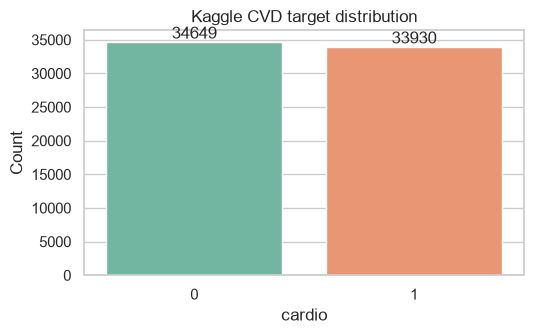

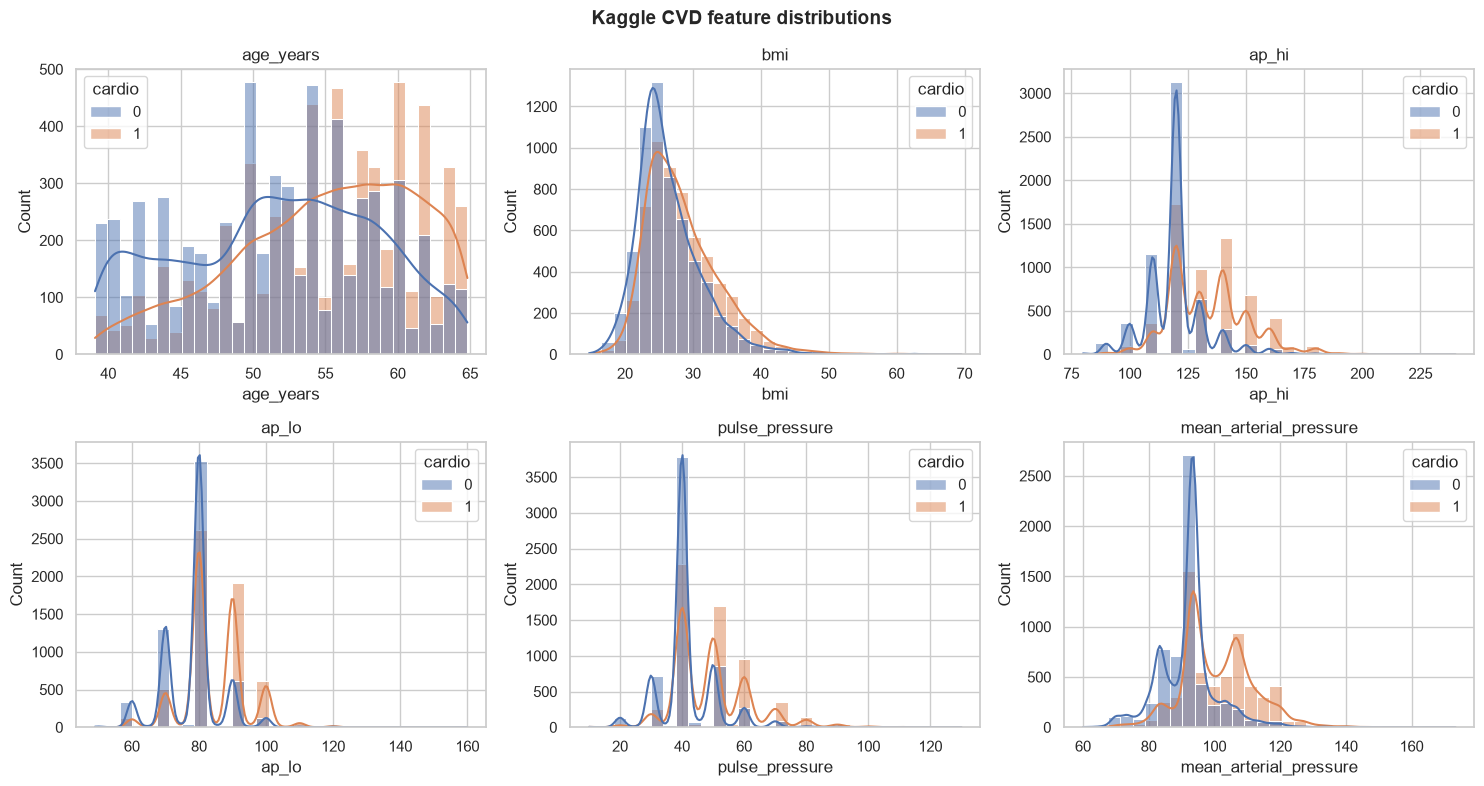

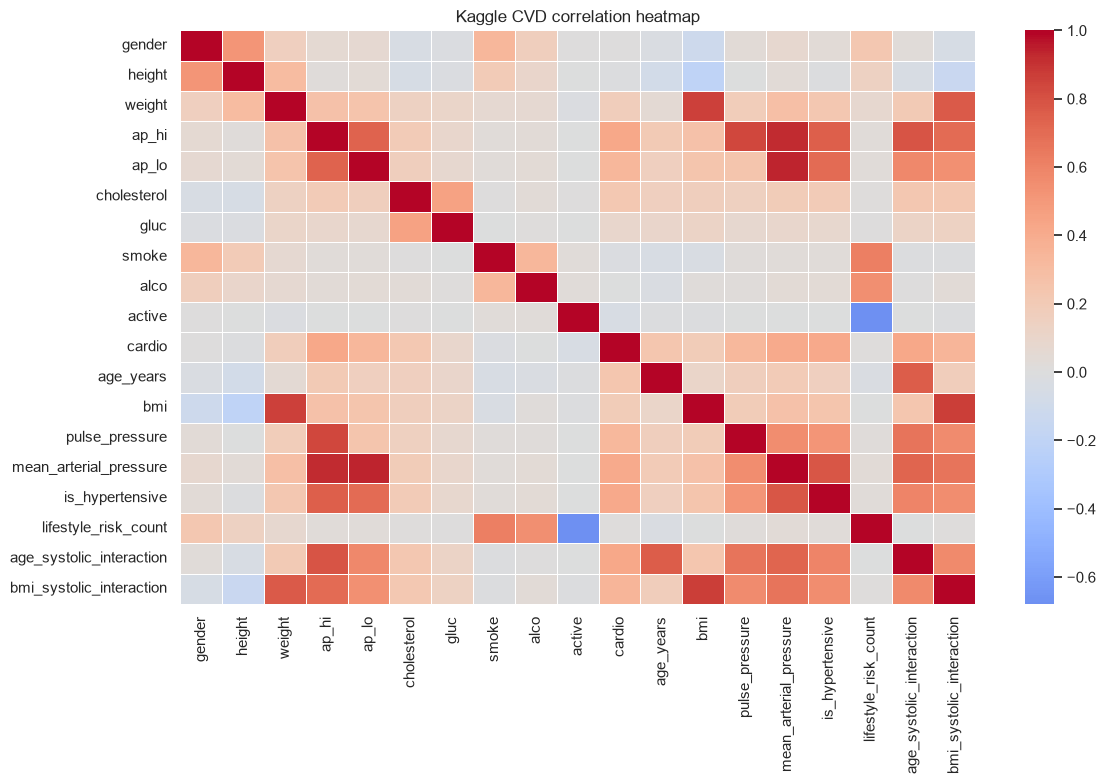

,model,threshold_type,threshold,fit_seconds,accuracy,precision,recall,f1,roc_auc,pr_auc
9,GradientBoostingClassifier,f1_tuned,0.39,24.549871,0.722295,0.690272,0.795756,0.739270,0.801343,0.782655
21,XGBClassifier,f1_tuned,0.38,1.540364,0.718212,0.682266,0.805629,0.738834,0.801499,0.784778
25,CatBoostClassifier,f1_tuned,0.40,4.739468,0.724191,0.695177,0.788093,0.738725,0.801621,0.782967
17,Neural Network 2,f1_tuned,0.34,5.557966,0.709536,0.666035,0.828176,0.738308,0.799852,0.780868
15,Neural Network 1,f1_tuned,0.34,3.307919,0.703631,0.656003,0.843059,0.737860,0.799559,0.780613
23,LGBMClassifier,f1_tuned,0.36,0.676550,0.709755,0.667343,0.824197,0.737522,0.801444,0.785128
3,Logistic Regression,f1_tuned,0.39,0.239910,0.711359,0.672189,0.813145,0.735979,0.794961,0.773295
19,SGDClassifier,f1_tuned,0.39,0.259311,0.705672,0.661687,0.828912,0.735919,0.793522,0.771466
7,ExtraTreesClassifier,f1_tuned,0.36,5.147307,0.704870,0.660794,0.829060,0.735425,0.798421,0.781708
11,Decision Tree Classifier,f1_tuned,0.35,0.318686,0.697507,0.652445,0.831565,0.731195,0.789058,0.760153


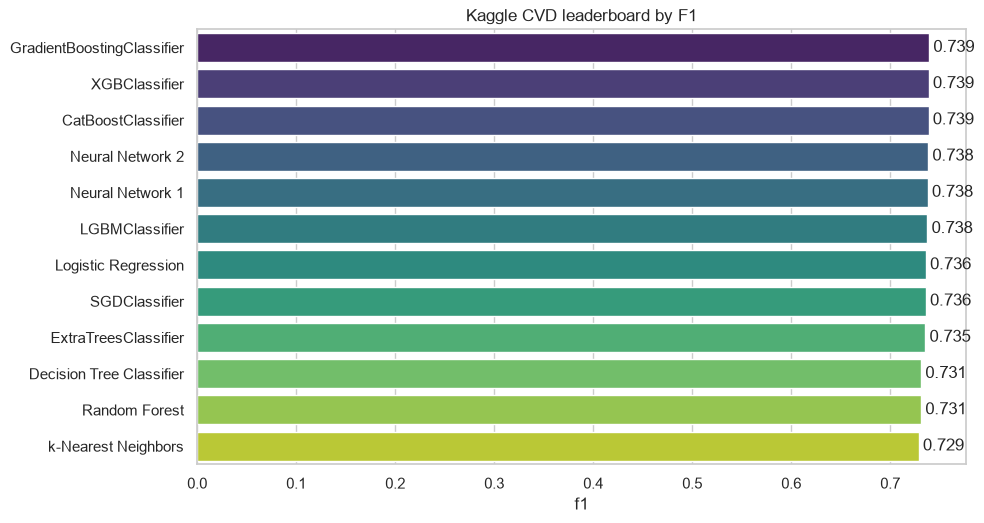

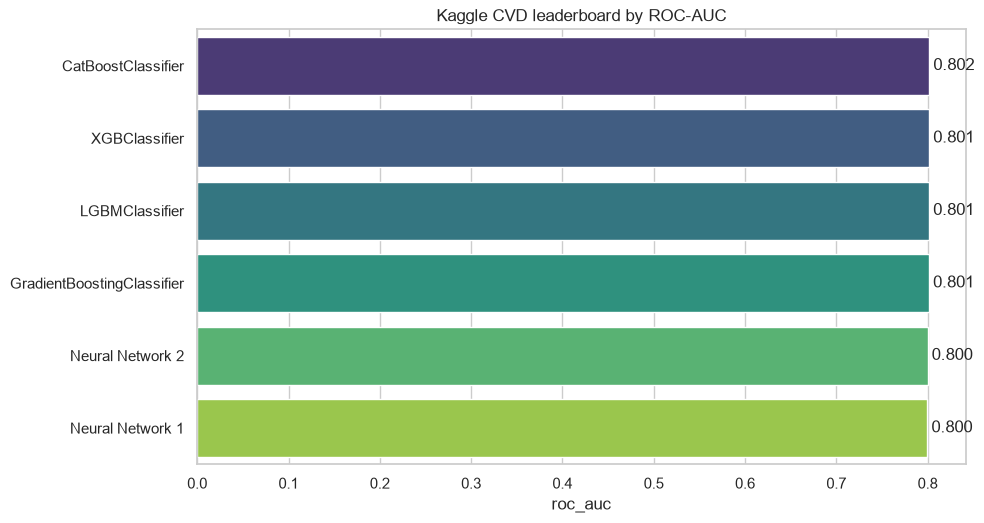

In [14]:
if CONFIG.run_kaggle_experiment:
    kaggle_raw = load_kaggle_cvd(CONFIG.project_root)
    kaggle_data = clean_kaggle_cvd(kaggle_raw)
    show_dataframe_info(kaggle_data, "cardio", "Kaggle CVD cleaned dataset")
    plot_target_distribution(kaggle_data, "cardio", "Kaggle CVD target distribution")
    plot_numeric_distributions(
        kaggle_data.sample(min(12000, len(kaggle_data)), random_state=CONFIG.random_state),
        "cardio",
        ["age_years", "bmi", "ap_hi", "ap_lo", "pulse_pressure", "mean_arterial_pressure"],
        "Kaggle CVD feature distributions",
    )
    plot_correlation_heatmap(kaggle_data, "Kaggle CVD correlation heatmap")

    kaggle_x, kaggle_y = split_features_target(kaggle_data, "cardio")
    kaggle_models = build_general_models(CONFIG.random_state)
    kaggle_results, kaggle_fitted_models, kaggle_test = evaluate_holdout_models(
        kaggle_x,
        kaggle_y,
        kaggle_models,
        build_kaggle_preprocessor,
        CONFIG.random_state,
    )
    display(kaggle_results)
    kaggle_results.to_csv(CONFIG.output_dir / "kaggle_results.csv", index=False)
    plot_leaderboard(kaggle_results, "f1", "Kaggle CVD leaderboard by F1")
    plot_leaderboard(kaggle_results, "roc_auc", "Kaggle CVD leaderboard by ROC-AUC")

## 8. Experiment: UCI Heart Disease Datasets

UCI Cleveland dataset
Shape: (303, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,cleveland


,dtype
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


,class,count,share
0,0,164,0.541254
1,1,139,0.458746


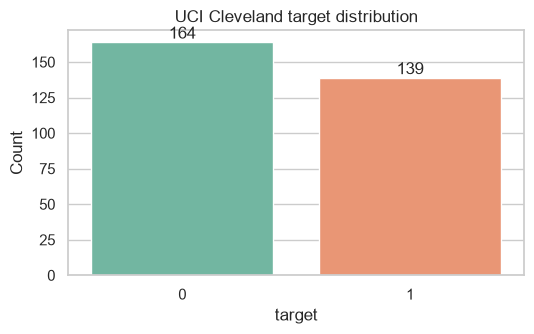

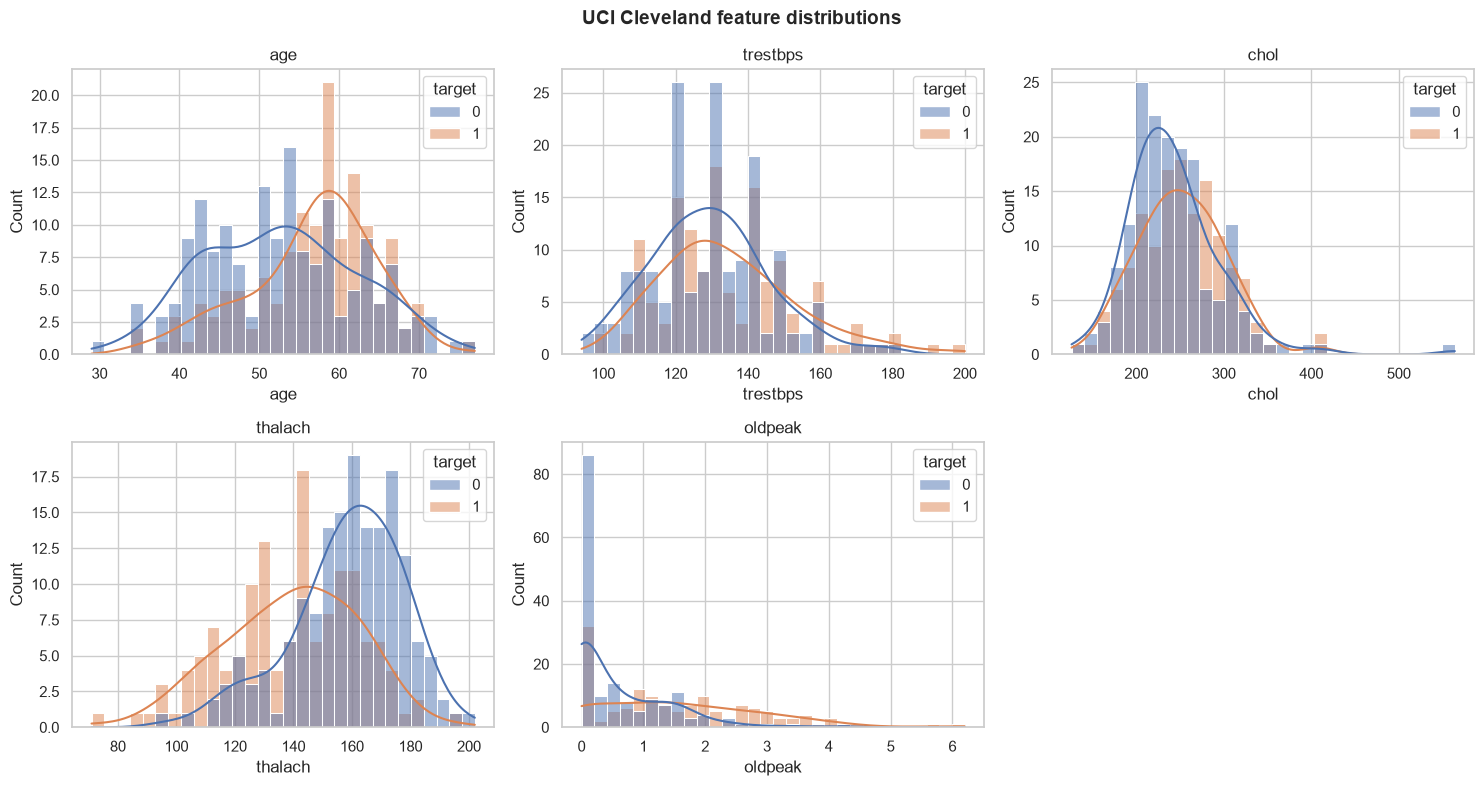

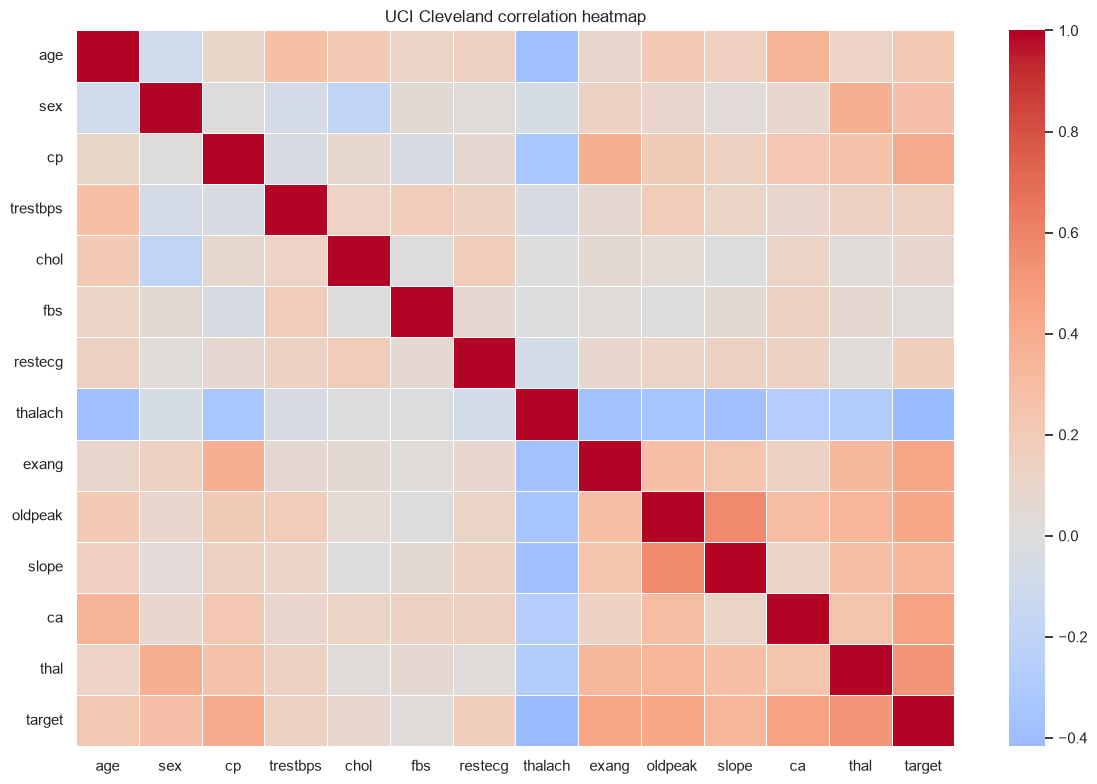

Evaluating Naive Bayes


Evaluating Logistic Regression


Evaluating SVC RBF
Evaluating Random Forest


Evaluating ExtraTreesClassifier


Evaluating Naive Bayes
Evaluating Logistic Regression
Evaluating SVC RBF


...

Evaluating ExtraTreesClassifier


UCI Cleveland results


,model,accuracy,accuracy_std,precision,recall,f1,roc_auc,roc_auc_std,pr_auc
0,Naive Bayes,0.854645,0.040315,0.863163,0.820106,0.838457,0.902211,0.023033,0.894929
3,Random Forest,0.834918,0.036317,0.841459,0.791005,0.814246,0.913703,0.018979,0.912853
4,ExtraTreesClassifier,0.831639,0.028833,0.825718,0.805291,0.813951,0.913590,0.020349,0.908969
1,Logistic Regression,0.824973,0.047713,0.819288,0.798413,0.806743,0.910981,0.017842,0.907378
2,SVC RBF,0.821694,0.038656,0.814875,0.798413,0.804806,0.897965,0.023162,0.897791


UCI all processed results


,model,accuracy,accuracy_std,precision,recall,f1,roc_auc,roc_auc_std,pr_auc
2,SVC RBF,0.820272,0.018084,0.842222,0.830732,0.836358,0.879483,0.021996,0.883422
4,ExtraTreesClassifier,0.818092,0.025566,0.845548,0.820889,0.832642,0.891866,0.023268,0.898291
0,Naive Bayes,0.816993,0.010642,0.866635,0.791303,0.827098,0.882397,0.019026,0.891269
1,Logistic Regression,0.815912,0.019178,0.850897,0.809105,0.829176,0.891497,0.017509,0.902923
3,Random Forest,0.808327,0.025033,0.828217,0.824888,0.826214,0.884434,0.022201,0.895960


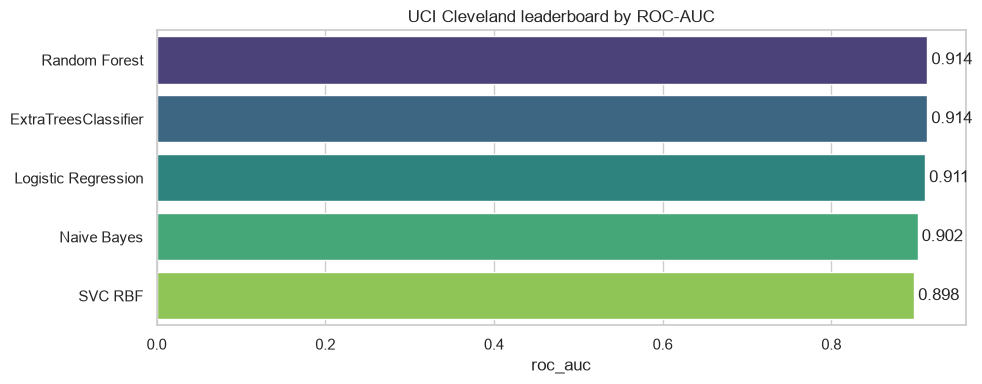

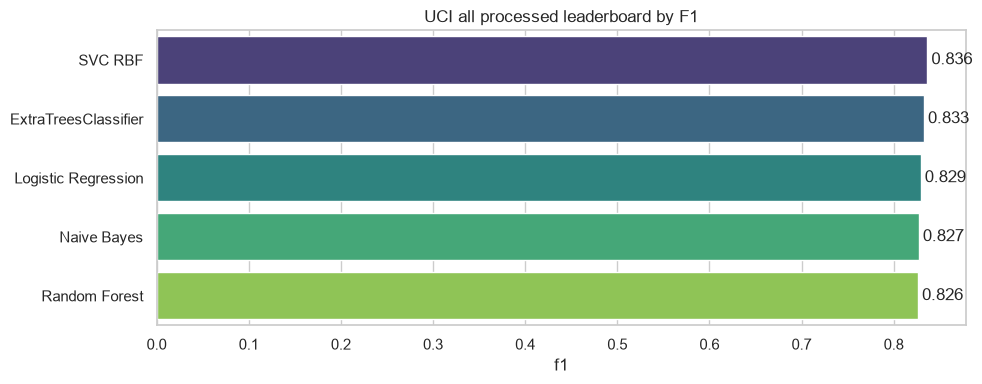

In [15]:
if CONFIG.run_uci_experiment:
    uci_paths = ensure_uci_datasets(CONFIG.project_root)
    uci_cohorts = {
        name: load_uci_file(path, name)
        for name, path in uci_paths.items()
    }
    uci_cleveland = clean_uci_data(uci_cohorts["cleveland"])
    uci_all = clean_uci_data(pd.concat(uci_cohorts.values(), ignore_index=True))

    show_dataframe_info(uci_cleveland, "target", "UCI Cleveland dataset")
    plot_target_distribution(uci_cleveland, "target", "UCI Cleveland target distribution")
    plot_numeric_distributions(
        uci_cleveland,
        "target",
        ["age", "trestbps", "chol", "thalach", "oldpeak"],
        "UCI Cleveland feature distributions",
    )
    plot_correlation_heatmap(uci_cleveland, "UCI Cleveland correlation heatmap")

    uci_models = {
        "Naive Bayes": GaussianNB(),
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=CONFIG.random_state,
        ),
        "SVC RBF": SVC(
            C=1.5,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=CONFIG.random_state,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=CONFIG.random_state,
            n_jobs=-1,
        ),
        "ExtraTreesClassifier": ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=CONFIG.random_state,
            n_jobs=-1,
        ),
    }

    uci_cleveland_x, uci_cleveland_y = split_features_target(uci_cleveland, "target")
    uci_all_x, uci_all_y = split_features_target(uci_all, "target")

    uci_cleveland_results = evaluate_cv_models(
        uci_cleveland_x,
        uci_cleveland_y,
        uci_models,
        build_uci_preprocessor,
        CONFIG.random_state,
        n_splits=5,
    )
    uci_all_results = evaluate_cv_models(
        uci_all_x,
        uci_all_y,
        uci_models,
        build_uci_preprocessor,
        CONFIG.random_state,
        n_splits=5,
    )

    print("UCI Cleveland results")
    display(uci_cleveland_results)
    print("UCI all processed results")
    display(uci_all_results)
    uci_cleveland_results.to_csv(CONFIG.output_dir / "uci_cleveland_results.csv", index=False)
    uci_all_results.to_csv(CONFIG.output_dir / "uci_all_results.csv", index=False)
    plot_leaderboard(uci_cleveland_results, "roc_auc", "UCI Cleveland leaderboard by ROC-AUC")
    plot_leaderboard(uci_all_results, "f1", "UCI all processed leaderboard by F1")

## 9. Experiment: OpenML Heart Disease Comprehensive 1190

OpenML Heart 1190 dataset
Shape: (1190, 12)


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,ST_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0


,dtype
age,float64
sex,float64
chest_pain_type,float64
resting_bp_s,float64
cholesterol,float64
fasting_blood_sugar,float64
resting_ecg,float64
max_heart_rate,float64
exercise_angina,float64
oldpeak,float64


,class,count,share
0,1,629,0.528571
1,0,561,0.471429


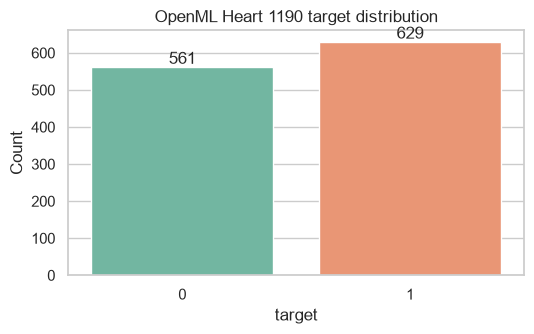

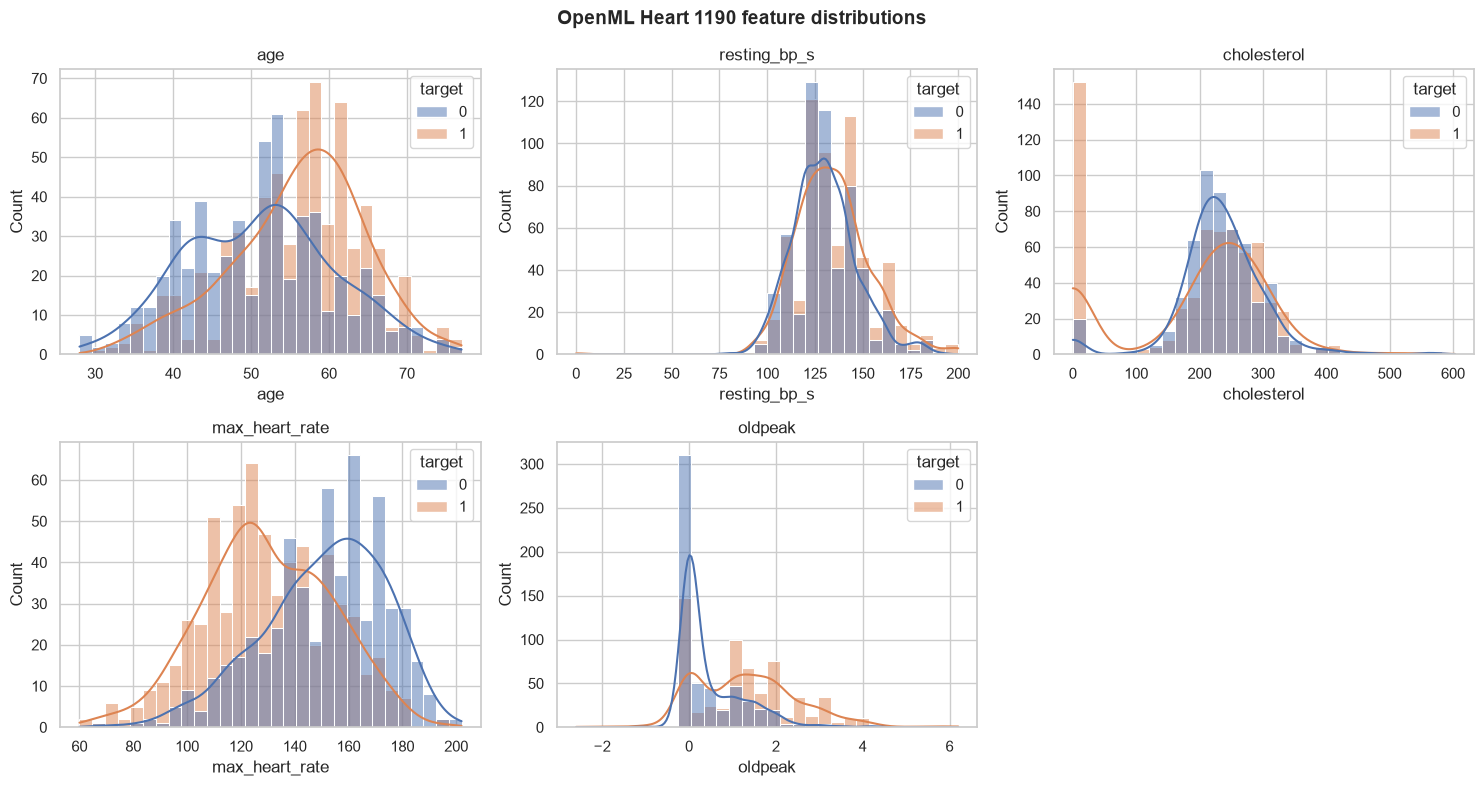

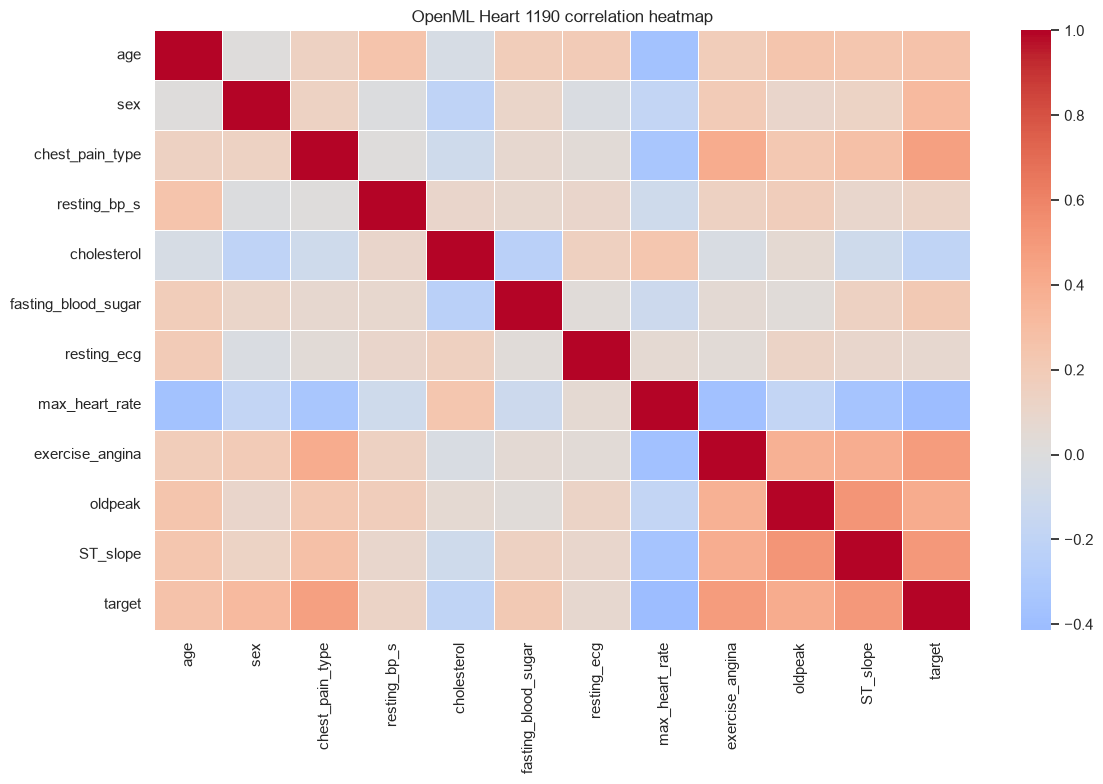

In [16]:
openml_data = load_openml_heart_1190(CONFIG.project_root)
show_dataframe_info(openml_data, "target", "OpenML Heart 1190 dataset")
plot_target_distribution(openml_data, "target", "OpenML Heart 1190 target distribution")
plot_numeric_distributions(
    openml_data,
    "target",
    ["age", "resting_bp_s", "cholesterol", "max_heart_rate", "oldpeak"],
    "OpenML Heart 1190 feature distributions",
)
plot_correlation_heatmap(openml_data, "OpenML Heart 1190 correlation heatmap")

openml_x, openml_y = split_features_target(openml_data, "target")

Evaluating Naive Bayes


Evaluating Logistic Regression


Evaluating SVC RBF


Evaluating Random Forest


Evaluating ExtraTreesClassifier


Evaluating GradientBoostingClassifier


Evaluating XGBClassifier


Evaluating LGBMClassifier


Evaluating CatBoostClassifier


,model,accuracy,accuracy_std,precision,recall,f1,roc_auc,roc_auc_std,pr_auc
6,XGBClassifier,0.920168,0.018506,0.930458,0.918894,0.924021,0.962822,0.010640,0.955763
8,CatBoostClassifier,0.917647,0.019455,0.922807,0.922069,0.921980,0.963984,0.011316,0.954096
3,Random Forest,0.910924,0.019600,0.914699,0.918894,0.916032,0.963559,0.011062,0.958103
4,ExtraTreesClassifier,0.889916,0.023604,0.892407,0.901382,0.896428,0.954916,0.011371,0.954854
7,LGBMClassifier,0.889916,0.022998,0.898824,0.893472,0.895543,0.949617,0.013610,0.946531
2,SVC RBF,0.872269,0.023105,0.872759,0.888710,0.880321,0.938026,0.016391,0.936956
5,GradientBoostingClassifier,0.863866,0.029062,0.864137,0.882284,0.872624,0.933689,0.013721,0.932779
1,Logistic Regression,0.847059,0.026521,0.852276,0.861598,0.856294,0.917312,0.020479,0.924296
0,Naive Bayes,0.784874,0.038178,0.920660,0.653405,0.758886,0.908411,0.013227,0.912257


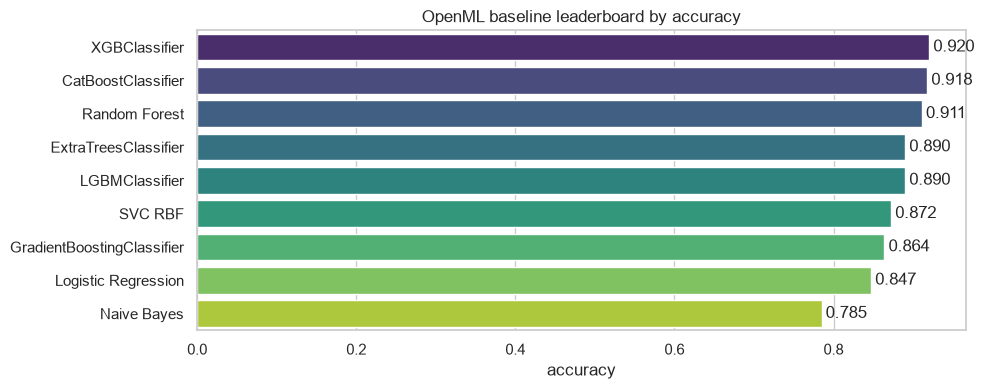

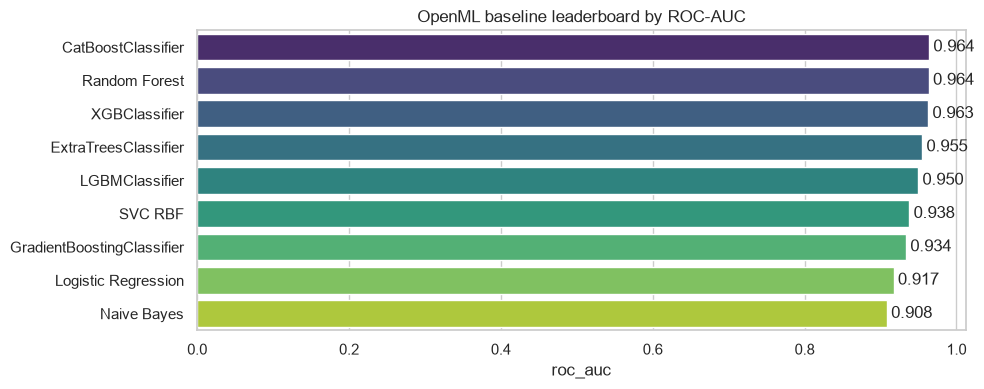

In [17]:
if CONFIG.run_openml_benchmark:
    openml_baseline_models = {
        "Naive Bayes": GaussianNB(),
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=CONFIG.random_state,
        ),
        "SVC RBF": SVC(
            C=2.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=CONFIG.random_state,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=CONFIG.random_state,
            n_jobs=-1,
        ),
        "ExtraTreesClassifier": ExtraTreesClassifier(
            n_estimators=500,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=CONFIG.random_state,
            n_jobs=-1,
        ),
        "GradientBoostingClassifier": GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.04,
            max_depth=2,
            random_state=CONFIG.random_state,
        ),
    }
    optional_models = build_general_models(CONFIG.random_state)
    for name in ["XGBClassifier", "LGBMClassifier", "CatBoostClassifier"]:
        if name in optional_models:
            openml_baseline_models[name] = optional_models[name]

    openml_benchmark_results = evaluate_cv_models(
        openml_x,
        openml_y,
        openml_baseline_models,
        build_openml_preprocessor,
        CONFIG.random_state,
        n_splits=10,
    )
    display(openml_benchmark_results)
    openml_benchmark_results.to_csv(CONFIG.output_dir / "openml_baseline_results.csv", index=False)
    plot_leaderboard(openml_benchmark_results, "accuracy", "OpenML baseline leaderboard by accuracy")
    plot_leaderboard(openml_benchmark_results, "roc_auc", "OpenML baseline leaderboard by ROC-AUC")

## 10. Hyperparameter-Tuned OpenML Models And Hybrids

Evaluating Tuned Random Forest


Evaluating Tuned ExtraTreesClassifier


Evaluating Tuned LGBMClassifier


Evaluating Tuned XGBClassifier


Evaluating Tuned CatBoostClassifier


Evaluating Tuned Soft Voting Hybrid


Evaluating Tuned Stacking Hybrid


,model,accuracy,accuracy_std,precision,recall,f1,roc_auc,roc_auc_std,pr_auc
4,Tuned CatBoostClassifier,0.942577,0.020821,0.943756,0.948558,0.945637,0.967789,0.015530,0.958571
5,Tuned Soft Voting Hybrid,0.941737,0.015934,0.938912,0.952287,0.945184,0.972143,0.014298,0.966343
6,Tuned Stacking Hybrid,0.940616,0.016797,0.940267,0.948583,0.943984,0.971907,0.014411,0.966109
2,Tuned LGBMClassifier,0.938095,0.017151,0.938961,0.944871,0.941543,0.969027,0.016035,0.959994
1,Tuned ExtraTreesClassifier,0.934174,0.015508,0.931298,0.945955,0.938103,0.969190,0.010510,0.965046
3,Tuned XGBClassifier,0.932773,0.017627,0.932800,0.941159,0.936576,0.963718,0.016330,0.954136
0,Tuned Random Forest,0.930532,0.018274,0.929633,0.940647,0.934700,0.967467,0.014513,0.960804


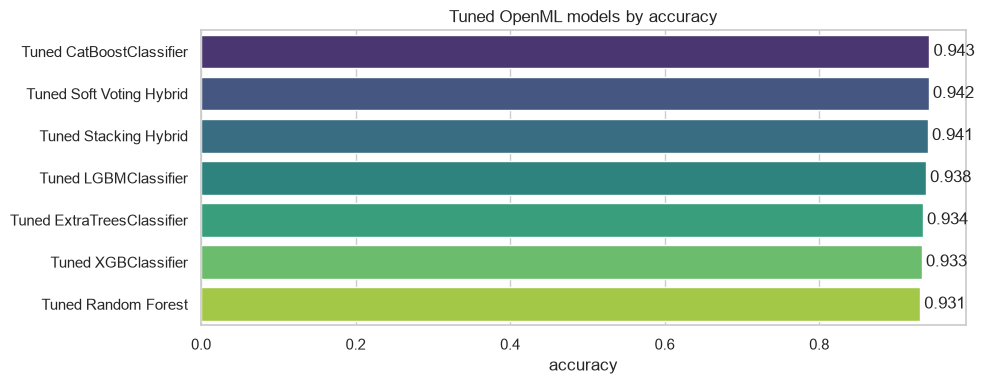

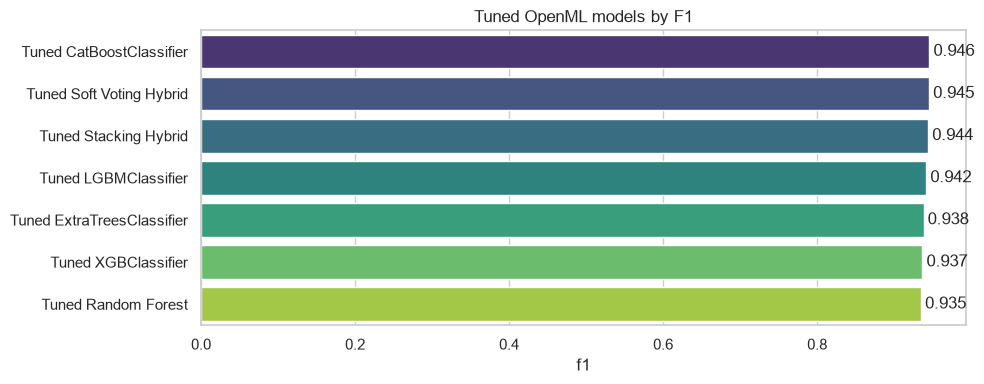

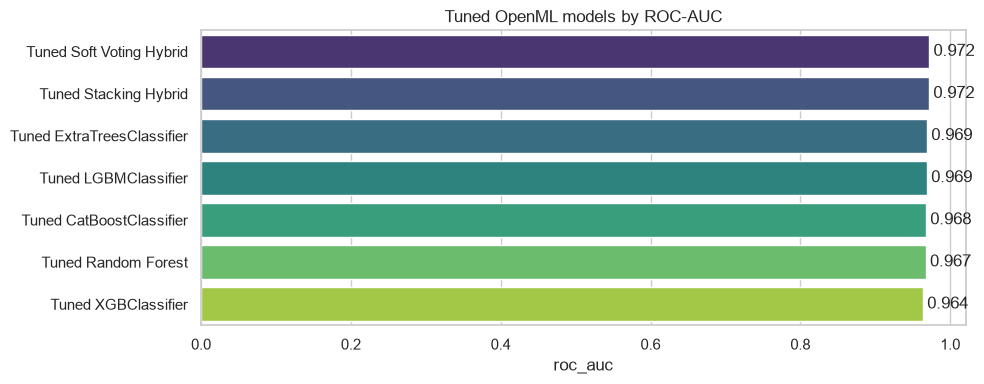

In [18]:
if CONFIG.run_openml_tuning:
    tuned_base_models = build_tuned_openml_models(CONFIG.random_state)
    tuned_hybrid_models = build_hybrid_models(tuned_base_models, CONFIG.random_state)
    tuned_all_models = {**tuned_base_models, **tuned_hybrid_models}

    tuned_results = evaluate_cv_models(
        openml_x,
        openml_y,
        tuned_all_models,
        build_openml_preprocessor,
        CONFIG.random_state,
        n_splits=10,
        n_repeats=3,
    )
    display(tuned_results)
    tuned_results.to_csv(CONFIG.output_dir / "openml_tuned_repeated_cv_results.csv", index=False)
    plot_leaderboard(tuned_results, "accuracy", "Tuned OpenML models by accuracy")
    plot_leaderboard(tuned_results, "f1", "Tuned OpenML models by F1")
    plot_leaderboard(tuned_results, "roc_auc", "Tuned OpenML models by ROC-AUC")

## 11. Feature Selection Experiments

Evaluating ANOVA SelectKBest + Tuned XGB


Evaluating Mutual Information SelectKBest + Tuned XGB


Evaluating ANOVA SelectKBest + Tuned CatBoost


,model,accuracy,accuracy_std,precision,recall,f1,roc_auc,roc_auc_std,pr_auc
1,Mutual Information SelectKBest + Tuned XGB,0.905602,0.024033,0.918674,0.902449,0.909958,0.951398,0.020193,0.942212
2,ANOVA SelectKBest + Tuned CatBoost,0.884874,0.027629,0.897080,0.884946,0.889981,0.937362,0.020878,0.933815
0,ANOVA SelectKBest + Tuned XGB,0.874230,0.029550,0.891201,0.869594,0.879432,0.927060,0.026082,0.927219


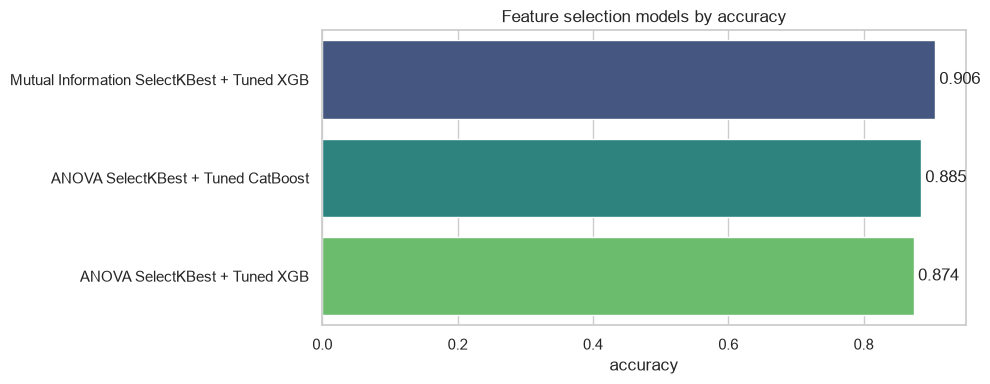

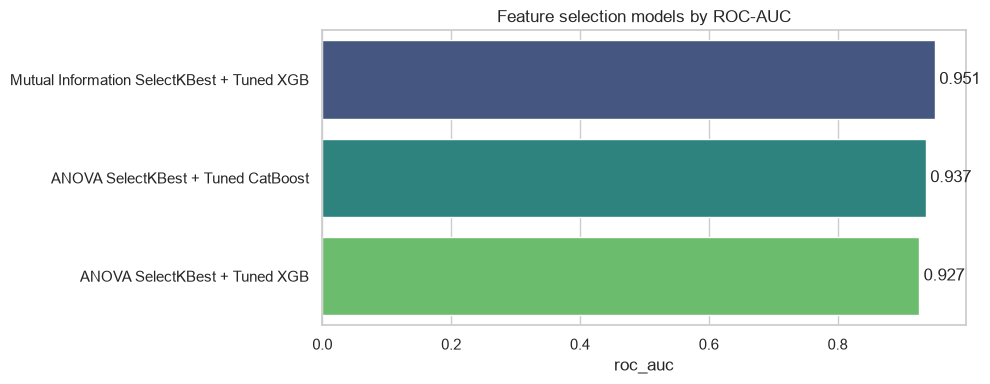

,feature,score
0,chest_pain_type_4.0,0.165816
1,ST_slope_1.0,0.154187
2,exercise_angina_1.0,0.148949
3,oldpeak,0.131548
4,max_heart_rate,0.129970
5,ST_slope_2.0,0.117181
6,exercise_angina_0.0,0.113296
7,cholesterol,0.107048


In [19]:
if CONFIG.run_feature_selection_experiment:
    feature_selection_models = build_feature_selection_models(CONFIG.random_state)
    feature_selection_results = evaluate_cv_models(
        openml_x,
        openml_y,
        feature_selection_models,
        build_openml_preprocessor,
        CONFIG.random_state,
        n_splits=10,
        n_repeats=3,
    )
    display(feature_selection_results)
    feature_selection_results.to_csv(
        CONFIG.output_dir / "feature_selection_repeated_cv_results.csv",
        index=False,
    )
    plot_leaderboard(
        feature_selection_results,
        "accuracy",
        "Feature selection models by accuracy",
    )
    plot_leaderboard(
        feature_selection_results,
        "roc_auc",
        "Feature selection models by ROC-AUC",
    )

    selected_feature_pipeline = build_pipeline(
        clone(feature_selection_models[feature_selection_results.iloc[0]["model"]]),
        build_openml_preprocessor(openml_x),
    )
    selected_feature_pipeline.fit(openml_x, openml_y)
    selected_features = extract_selected_features(selected_feature_pipeline)
    display(selected_features)
    selected_features.to_csv(CONFIG.output_dir / "selected_features.csv", index=False)

## 12. Feature Tokenizer Transformer Experiment

,model,epochs,best_valid_auc,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Feature Tokenizer Transformer,24,0.940704,0.882353,0.865672,0.920635,0.892308,0.928005,0.903255


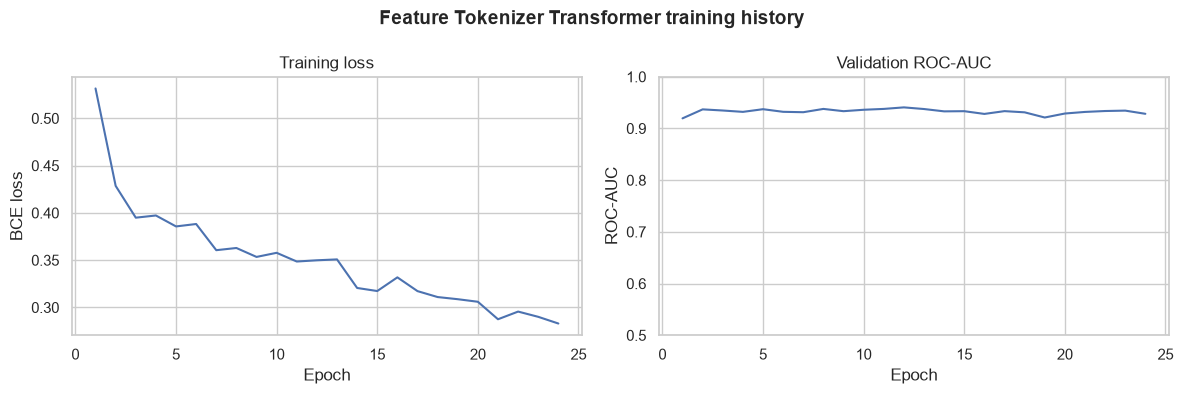

In [20]:
if CONFIG.run_ft_transformer_experiment:
    ft_transformer_results, ft_transformer_model, ft_preprocessor, ft_history = (
        train_ft_transformer_holdout(
            openml_x,
            openml_y,
            build_openml_preprocessor,
            CONFIG.random_state,
            max_epochs=CONFIG.ft_transformer_epochs,
        )
    )
    display(ft_transformer_results)
    ft_transformer_results.to_csv(
        CONFIG.output_dir / "ft_transformer_holdout_results.csv",
        index=False,
    )
    plot_training_history(ft_history, "Feature Tokenizer Transformer training history")

## 13. Visual Evaluation Of Final Models

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
2,Tuned Stacking Hybrid,0.928571,0.950413,0.912698,0.931174,0.973994,0.969033
1,Tuned Soft Voting Hybrid,0.928571,0.943089,0.920635,0.931727,0.973569,0.969116
0,Tuned CatBoostClassifier,0.924370,0.950000,0.904762,0.926829,0.967545,0.960799


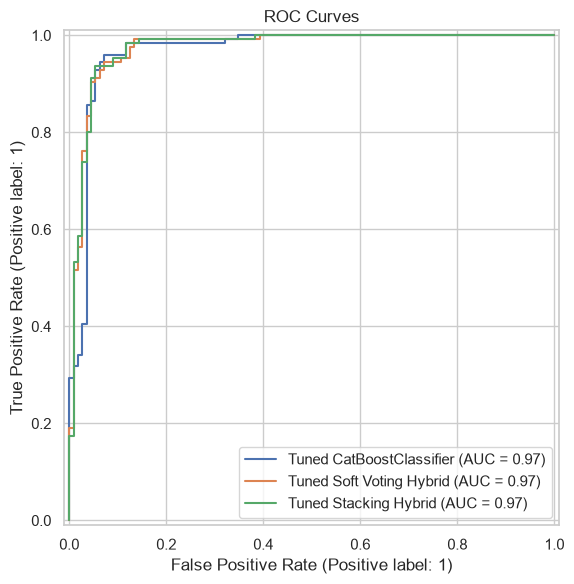

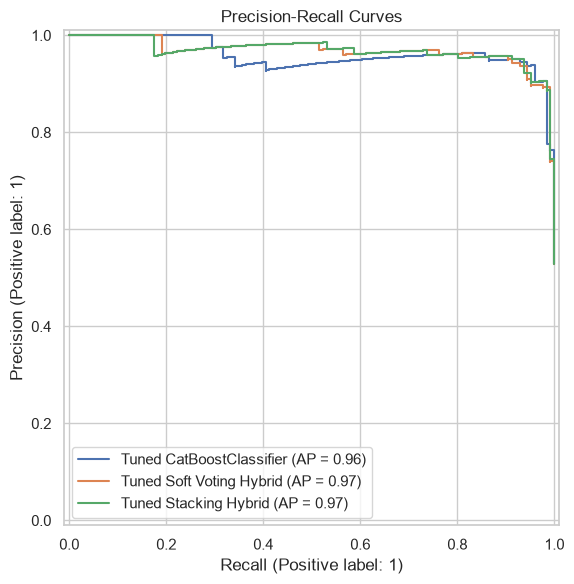

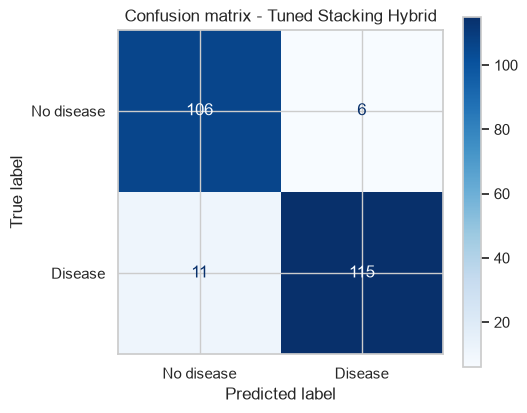

In [21]:
final_models = {}
if "tuned_base_models" in globals():
    if "Tuned CatBoostClassifier" in tuned_base_models:
        final_models["Tuned CatBoostClassifier"] = tuned_base_models["Tuned CatBoostClassifier"]
    if "Tuned Soft Voting Hybrid" in tuned_hybrid_models:
        final_models["Tuned Soft Voting Hybrid"] = tuned_hybrid_models["Tuned Soft Voting Hybrid"]
    if "Tuned Stacking Hybrid" in tuned_hybrid_models:
        final_models["Tuned Stacking Hybrid"] = tuned_hybrid_models["Tuned Stacking Hybrid"]

x_train, x_test, y_train, y_test = train_test_split(
    openml_x,
    openml_y,
    test_size=0.2,
    random_state=CONFIG.random_state,
    stratify=openml_y,
)

final_fitted_models: dict[str, Pipeline] = {}
final_holdout_rows: list[dict[str, float | str]] = []
for model_name, estimator in final_models.items():
    pipeline = build_pipeline(clone(estimator), build_openml_preprocessor(x_train))
    pipeline.fit(x_train, y_train)
    probabilities = predict_positive_probability(pipeline, x_test)
    final_holdout_rows.append({"model": model_name, **compute_metrics(y_test, probabilities)})
    final_fitted_models[model_name] = pipeline

final_holdout_results = pd.DataFrame(final_holdout_rows).sort_values("roc_auc", ascending=False)
display(final_holdout_results)
final_holdout_results.to_csv(CONFIG.output_dir / "final_holdout_results.csv", index=False)

if final_fitted_models:
    plot_curve_outputs(final_fitted_models, x_test, y_test, list(final_fitted_models))
    best_model_name = final_holdout_results.iloc[0]["model"]
    plot_confusion_for_model(
        final_fitted_models[best_model_name],
        x_test,
        y_test,
        f"Confusion matrix - {best_model_name}",
    )

## 14. Feature Importance From Final Single Model

,feature,importance
0,cholesterol,14.217817
1,oldpeak,12.886585
2,max_heart_rate,12.054487
3,resting_bp_s,10.087451
4,age,9.631275
5,ST_slope_2.0,6.374532
6,chest_pain_type_4.0,6.258828
7,ST_slope_1.0,5.646601
8,resting_ecg_2.0,3.884824
9,sex_1.0,3.466388


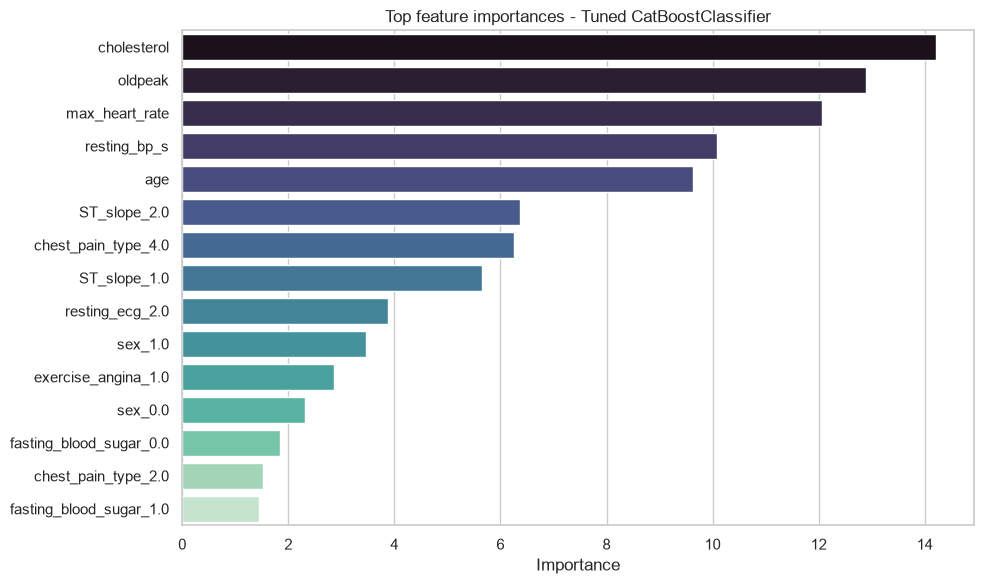

In [22]:
if "tuned_base_models" in globals() and "Tuned CatBoostClassifier" in tuned_base_models:
    feature_pipeline = build_pipeline(
        clone(tuned_base_models["Tuned CatBoostClassifier"]),
        build_openml_preprocessor(openml_x),
    )
    feature_pipeline.fit(openml_x, openml_y)
    preprocessor = feature_pipeline.named_steps["preprocessor"]
    classifier = feature_pipeline.named_steps["classifier"]

    if hasattr(classifier, "feature_importances_"):
        feature_importance = (
            pd.DataFrame(
                {
                    "feature": preprocessor.get_feature_names_out(),
                    "importance": classifier.feature_importances_,
                }
            )
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
        display(feature_importance)
        feature_importance.to_csv(CONFIG.output_dir / "feature_importance.csv", index=False)

        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(
            data=feature_importance.head(15),
            x="importance",
            y="feature",
            ax=ax,
            palette="mako",
        )
        ax.set_title("Top feature importances - Tuned CatBoostClassifier")
        ax.set_xlabel("Importance")
        ax.set_ylabel("")
        fig.tight_layout()
        plt.show()

## 15. SHAP Explainability For The Final Tree-Based Model

,feature,mean_abs_shap
0,chest_pain_type_4.0,1.090112
1,ST_slope_2.0,0.982498
2,oldpeak,0.860191
3,ST_slope_1.0,0.855849
4,cholesterol,0.773262
5,max_heart_rate,0.596817
6,exercise_angina_1.0,0.588940
7,sex_1.0,0.516538
8,age,0.494082
9,resting_bp_s,0.426926


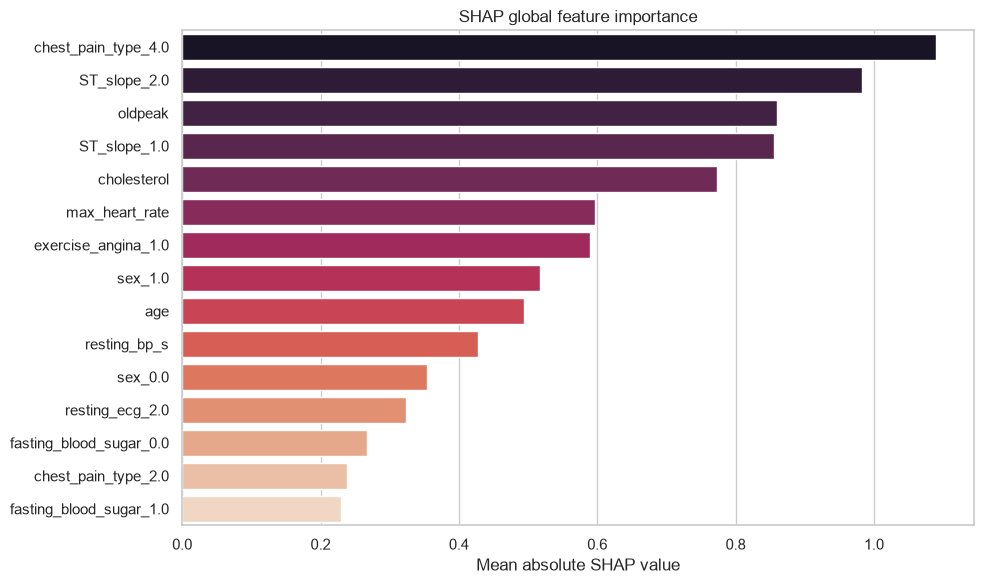

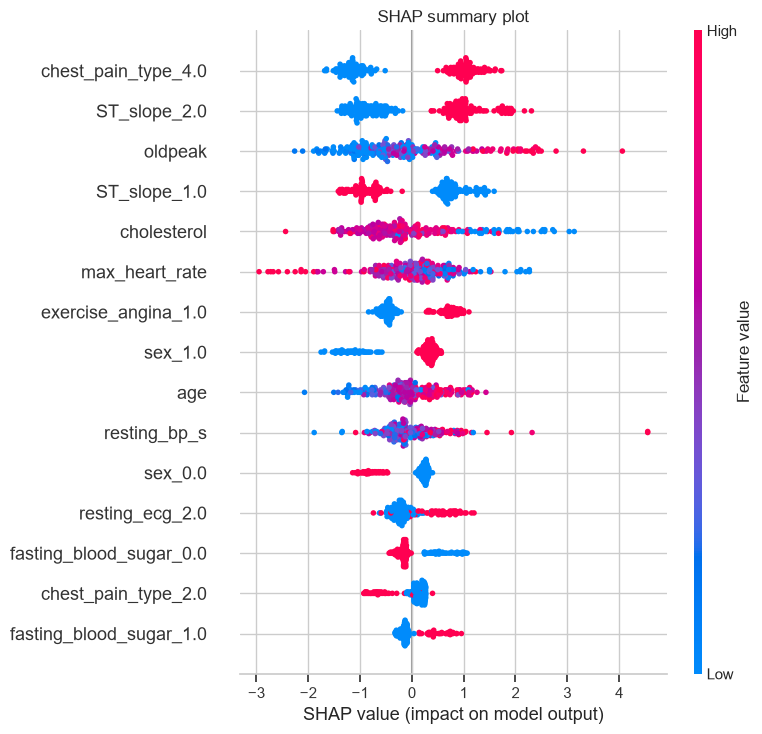

In [23]:
if CONFIG.run_xai_experiment and "feature_pipeline" in globals():
    try:
        shap_importance = run_shap_explainability(
            feature_pipeline,
            openml_x,
            CONFIG.output_dir,
            sample_size=250,
        )
    except ImportError as exc:
        print(exc)

## 16. Final Dataset Comparison

,dataset,model,accuracy,f1,recall,roc_auc
0,Kaggle CVD 70k,GradientBoostingClassifier,0.722295,0.739270,0.795756,0.801343
1,UCI Cleveland,Random Forest,0.834918,0.814246,0.791005,0.913703
2,UCI All Processed,SVC RBF,0.820272,0.836358,0.830732,0.879483
3,OpenML Heart 1190,Tuned CatBoostClassifier,0.942577,0.945637,0.948558,0.967789
4,OpenML Heart 1190,Tuned Soft Voting Hybrid,0.941737,0.945184,0.952287,0.972143
5,OpenML Heart 1190 + Feature Selection,Mutual Information SelectKBest + Tuned XGB,0.905602,0.909958,0.902449,0.951398
6,OpenML Heart 1190 + FT-Transformer,Feature Tokenizer Transformer,0.882353,0.892308,0.920635,0.928005


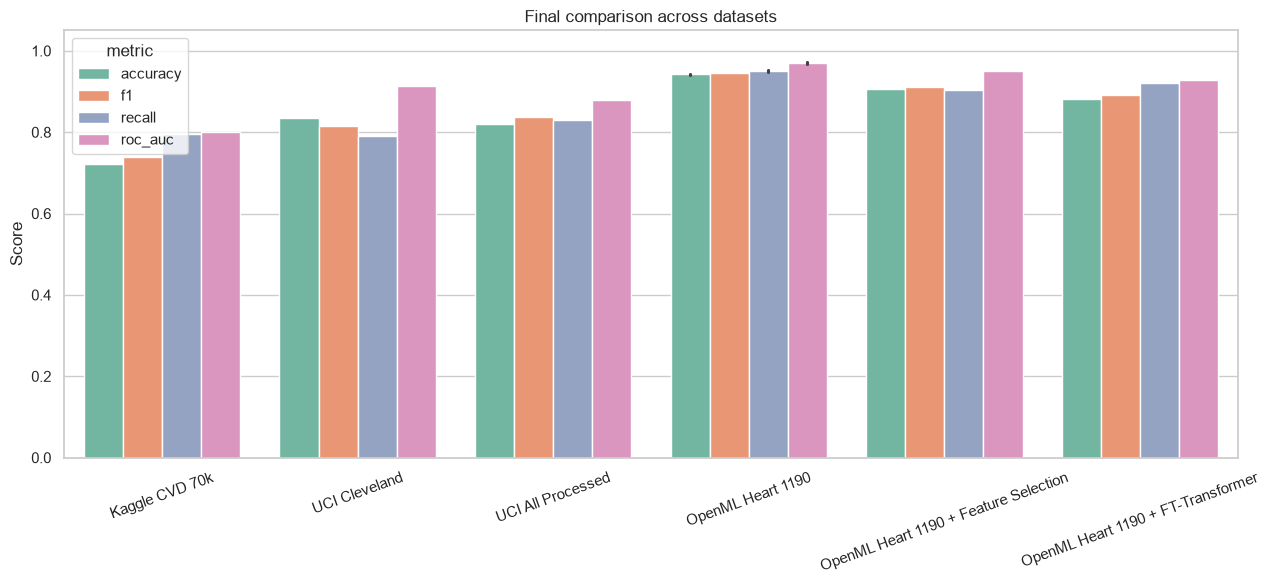

In [24]:
comparison_frames = []

if "kaggle_results" in globals():
    top_kaggle = kaggle_results.sort_values("f1", ascending=False).head(1).copy()
    top_kaggle.insert(0, "dataset", "Kaggle CVD 70k")
    comparison_frames.append(top_kaggle[["dataset", "model", "accuracy", "f1", "recall", "roc_auc"]])

if "uci_cleveland_results" in globals():
    top_uci = uci_cleveland_results.sort_values("roc_auc", ascending=False).head(1).copy()
    top_uci.insert(0, "dataset", "UCI Cleveland")
    comparison_frames.append(top_uci[["dataset", "model", "accuracy", "f1", "recall", "roc_auc"]])

if "uci_all_results" in globals():
    top_uci_all = uci_all_results.sort_values("f1", ascending=False).head(1).copy()
    top_uci_all.insert(0, "dataset", "UCI All Processed")
    comparison_frames.append(top_uci_all[["dataset", "model", "accuracy", "f1", "recall", "roc_auc"]])

if "tuned_results" in globals():
    top_openml = tuned_results.sort_values("accuracy", ascending=False).head(1).copy()
    top_openml.insert(0, "dataset", "OpenML Heart 1190")
    comparison_frames.append(top_openml[["dataset", "model", "accuracy", "f1", "recall", "roc_auc"]])

    top_openml_auc = tuned_results.sort_values("roc_auc", ascending=False).head(1).copy()
    top_openml_auc.insert(0, "dataset", "OpenML Heart 1190")
    comparison_frames.append(top_openml_auc[["dataset", "model", "accuracy", "f1", "recall", "roc_auc"]])

if "feature_selection_results" in globals():
    top_fs = feature_selection_results.sort_values("roc_auc", ascending=False).head(1).copy()
    top_fs.insert(0, "dataset", "OpenML Heart 1190 + Feature Selection")
    comparison_frames.append(top_fs[["dataset", "model", "accuracy", "f1", "recall", "roc_auc"]])

if "ft_transformer_results" in globals():
    top_ft = ft_transformer_results.copy()
    top_ft.insert(0, "dataset", "OpenML Heart 1190 + FT-Transformer")
    comparison_frames.append(top_ft[["dataset", "model", "accuracy", "f1", "recall", "roc_auc"]])

final_comparison = pd.concat(comparison_frames, ignore_index=True)
display(final_comparison)
final_comparison.to_csv(CONFIG.output_dir / "final_dataset_comparison.csv", index=False)

plot_data = final_comparison.melt(
    id_vars=["dataset", "model"],
    value_vars=["accuracy", "f1", "recall", "roc_auc"],
    var_name="metric",
    value_name="score",
)
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=plot_data, x="dataset", y="score", hue="metric", ax=ax, palette="Set2")
ax.set_title("Final comparison across datasets")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

## 17. Comparison With Published Work

In [25]:
published_work_comparison = pd.DataFrame(
    [
        {
            "study": "Ensemble learning with explainable AI, Scientific Reports 2025",
            "dataset": "HDDC / D1",
            "method": "Stacking ensemble",
            "accuracy": "91%",
            "sensitivity_recall": "Not reported in summary line",
            "roc_auc": "0.92",
            "comparison_type": "Same family of heart-disease benchmark; protocol differs",
            "source": "https://www.nature.com/articles/s41598-025-97547-6",
        },
        {
            "study": "Ensemble learning with explainable AI, Scientific Reports 2025",
            "dataset": "UHDD / D2",
            "method": "Stacking ensemble",
            "accuracy": "98%",
            "sensitivity_recall": "Not reported in summary line",
            "roc_auc": "0.97",
            "comparison_type": "Same family of heart-disease benchmark; protocol differs",
            "source": "https://www.nature.com/articles/s41598-025-97547-6",
        },
        {
            "study": "Optimized Ensemble Learning with XAI, Information 2024",
            "dataset": "Cleveland",
            "method": "Bayesian-optimized XGBoost + SHAP",
            "accuracy": "98.40%",
            "sensitivity_recall": "98.90%",
            "roc_auc": "Not reported in Table 5",
            "comparison_type": "Dataset overlaps with UCI Cleveland; protocol differs",
            "source": "https://pdfs.semanticscholar.org/3747/6c8130d1b63c9b1894870c9243026c98a24e.pdf",
        },
        {
            "study": "Optimized Ensemble Learning with XAI, Information 2024",
            "dataset": "Framingham",
            "method": "Bayesian-optimized XGBoost + SHAP",
            "accuracy": "95.90%",
            "sensitivity_recall": "97.50%",
            "roc_auc": "Not reported in Table 6",
            "comparison_type": "Different dataset; indirect comparison only",
            "source": "https://pdfs.semanticscholar.org/3747/6c8130d1b63c9b1894870c9243026c98a24e.pdf",
        },
        {
            "study": "This work",
            "dataset": "OpenML Heart 1190",
            "method": "Tuned CatBoostClassifier",
            "accuracy": f"{tuned_results.sort_values('accuracy', ascending=False).iloc[0]['accuracy'] * 100:.2f}%",
            "sensitivity_recall": f"{tuned_results.sort_values('accuracy', ascending=False).iloc[0]['recall'] * 100:.2f}%",
            "roc_auc": f"{tuned_results.sort_values('accuracy', ascending=False).iloc[0]['roc_auc']:.4f}",
            "comparison_type": "Our reproducible repeated-CV result",
            "source": "Generated by this notebook",
        },
        {
            "study": "This work",
            "dataset": "OpenML Heart 1190",
            "method": "Tuned Soft Voting Hybrid",
            "accuracy": f"{tuned_results.sort_values('roc_auc', ascending=False).iloc[0]['accuracy'] * 100:.2f}%",
            "sensitivity_recall": f"{tuned_results.sort_values('roc_auc', ascending=False).iloc[0]['recall'] * 100:.2f}%",
            "roc_auc": f"{tuned_results.sort_values('roc_auc', ascending=False).iloc[0]['roc_auc']:.4f}",
            "comparison_type": "Our reproducible repeated-CV hybrid result",
            "source": "Generated by this notebook",
        },
        {
            "study": "This work",
            "dataset": "OpenML Heart 1190 + FT-Transformer",
            "method": "Feature Tokenizer Transformer",
            "accuracy": f"{ft_transformer_results.iloc[0]['accuracy'] * 100:.2f}%" if "ft_transformer_results" in globals() else "Not run",
            "sensitivity_recall": f"{ft_transformer_results.iloc[0]['recall'] * 100:.2f}%" if "ft_transformer_results" in globals() else "Not run",
            "roc_auc": f"{ft_transformer_results.iloc[0]['roc_auc']:.4f}" if "ft_transformer_results" in globals() else "Not run",
            "comparison_type": "Our deep tabular baseline",
            "source": "Generated by this notebook",
        },
    ]
)
display(published_work_comparison)
published_work_comparison.to_csv(
    CONFIG.output_dir / "published_work_comparison.csv",
    index=False,
)

,study,dataset,method,accuracy,sensitivity_recall,roc_auc,comparison_type,source
0,"Ensemble learning with explainable AI, Scienti...",HDDC / D1,Stacking ensemble,91%,Not reported in summary line,0.92,Same family of heart-disease benchmark; protoc...,https://www.nature.com/articles/s41598-025-975...
1,"Ensemble learning with explainable AI, Scienti...",UHDD / D2,Stacking ensemble,98%,Not reported in summary line,0.97,Same family of heart-disease benchmark; protoc...,https://www.nature.com/articles/s41598-025-975...
2,"Optimized Ensemble Learning with XAI, Informat...",Cleveland,Bayesian-optimized XGBoost + SHAP,98.40%,98.90%,Not reported in Table 5,Dataset overlaps with UCI Cleveland; protocol ...,https://pdfs.semanticscholar.org/3747/6c8130d1...
3,"Optimized Ensemble Learning with XAI, Informat...",Framingham,Bayesian-optimized XGBoost + SHAP,95.90%,97.50%,Not reported in Table 6,Different dataset; indirect comparison only,https://pdfs.semanticscholar.org/3747/6c8130d1...
4,This work,OpenML Heart 1190,Tuned CatBoostClassifier,94.26%,94.86%,0.9678,Our reproducible repeated-CV result,Generated by this notebook
5,This work,OpenML Heart 1190,Tuned Soft Voting Hybrid,94.17%,95.23%,0.9721,Our reproducible repeated-CV hybrid result,Generated by this notebook
6,This work,OpenML Heart 1190 + FT-Transformer,Feature Tokenizer Transformer,88.24%,92.06%,0.9280,Our deep tabular baseline,Generated by this notebook


Direct comparison is valid only when the same dataset, split strategy, preprocessing,
and evaluation protocol are used. The published values above are therefore used to
position the work in the literature, while the reproducible results generated in this
notebook are reported separately.

## 18. Research Contribution Positioning

In [26]:
contribution_matrix = pd.DataFrame(
    [
        {
            "issue": "Using multiple datasets alone is not a sufficient contribution.",
            "project_response": "Treat multiple datasets as validation evidence, not as the main novelty.",
            "evidence": "Kaggle, UCI, OpenML, feature-selection, and FT-Transformer results are reported separately.",
        },
        {
            "issue": "A clear technical contribution is required.",
            "project_response": "Propose a unified explainable hybrid framework.",
            "evidence": "Soft Voting and Stacking hybrids combine tuned boosting and tree-ensemble learners.",
        },
        {
            "issue": "The model should not be a black box.",
            "project_response": "Add SHAP explainability for the final tree-based model.",
            "evidence": "SHAP identifies chest pain type, ST slope, oldpeak, cholesterol, max heart rate, and exercise angina.",
        },
        {
            "issue": "Deep learning should be represented if the thesis claims modern AI.",
            "project_response": "Add Feature Tokenizer Transformer for tabular clinical data.",
            "evidence": "FT-Transformer is evaluated as a deep tabular baseline and compared with boosting/hybrid models.",
        },
        {
            "issue": "Feature engineering/selection should be evaluated, not assumed.",
            "project_response": "Add ANOVA and mutual-information SelectKBest experiments.",
            "evidence": "Feature selection is shown to reduce dimensionality but does not outperform the full hybrid framework.",
        },
        {
            "issue": "High published accuracies may come from different protocols.",
            "project_response": "Separate published results from reproducible notebook-generated results.",
            "evidence": "Published-work comparison table includes a comparison-type note for each row.",
        },
    ]
)
display(contribution_matrix)
contribution_matrix.to_csv(CONFIG.output_dir / "research_contribution_matrix.csv", index=False)

,issue,project_response,evidence
0,Using multiple datasets alone is not a suffici...,Treat multiple datasets as validation evidence...,"Kaggle, UCI, OpenML, feature-selection, and FT..."
1,A clear technical contribution is required.,Propose a unified explainable hybrid framework.,Soft Voting and Stacking hybrids combine tuned...
2,The model should not be a black box.,Add SHAP explainability for the final tree-bas...,"SHAP identifies chest pain type, ST slope, old..."
3,Deep learning should be represented if the the...,Add Feature Tokenizer Transformer for tabular ...,FT-Transformer is evaluated as a deep tabular ...
4,Feature engineering/selection should be evalua...,Add ANOVA and mutual-information SelectKBest e...,Feature selection is shown to reduce dimension...
5,High published accuracies may come from differ...,Separate published results from reproducible n...,Published-work comparison table includes a com...


## 19. Final Notes

The final recommendation should be based on the generated outputs above:

- Use the strongest single model when the goal is maximum single-model performance.
- Use the strongest hybrid model when the goal is to support the proposed hybrid AI framework.
- Use SHAP plots when the goal is clinical interpretability.
- Use FT-Transformer results as a modern deep tabular learning contribution.
- Use multiple datasets as validation evidence, not as the sole research contribution.
- Use the published-work table to compare only under clearly stated dataset/protocol assumptions.
- Report metrics from cross-validation and avoid manually editing any result values.